# Part 5 — reconstruction: the `balanced_bce` family

Compares reconstruction quality across all six `balanced_bce`-head predictive-campaign
objectives (`grid_0006`/`nnpu` is a genuinely different head loss and is out of scope
here — see `part_6`'s intro for why it isn't directly comparable this way):

- `grid_0000` — `balanced_bce` alone. Same model `part_1`/`part_3`/`part_4` called
  "BCE."
- `grid_0001` — `+ contractive`: the encoder-Jacobian penalty verified in `part_4`.
  `part_4`/`part_7` found it produces the intended local-flatness effect but also
  collapses the latent cloud toward a single direction (`cloud_asymmetry` 0.96 vs.
  0.35-0.50 for every other objective, `part_7`) — the only one of these terms whose
  geometric effect survives the seed-noise null check.
- `grid_0002` — `+ peak_random`: InfoNCE with unannotated-and-annotated peaks permuted
  indiscriminately (a "does contrastive invariance help at all" control).
- `grid_0003` — `+ peak_label_invariant`: InfoNCE with annotated bins protected from
  permutation. The strongest single-term reconstruction effect found below.
- `grid_0004` — `+ contractive + peak_label_invariant`: layers the collapse-inducing
  penalty on top of the one term that measurably helped. **Key new question**: does
  `+contractive` help, hurt, or do nothing once added on top of
  `+peak_label_invariant` — i.e. is `grid_0003` → `grid_0004` an improvement?
- `grid_0005` — `grid_0004` `+ negw_multilabel_jaccard`: down-weights InfoNCE negative
  pairs by the Jaccard overlap of their annotated molecule sets (spectra sharing all
  their annotated molecules are barely penalized as "negatives" instead of being
  treated as fully distinct) — addresses InfoNCE's false-negative problem for spectra
  that are chemically near-identical. **Key new question**: does this change anything
  relative to `grid_0004`?

**Unlike `part_1`**, no pixel-intersection trick is needed here: all six objectives
share the exact same dataset/split (verified directly against their saved
`config.json` — identical `train`/`validation`/`test` spectrum-id assignments), so any
spectrum id is valid for every model without restricting to an overlap. Scope: **train
and test splits only** (validation not needed for this comparison, unlike `part_1`).

All comparisons go through the seed-noise null check established in `part_4`/`part_7`
before any difference is trusted — both the vs-`bce` comparisons and, new here, the two
immediate-predecessor links in the combination chain (`+peak_label_invariant` →
`grid_0004`, `grid_0004` → `grid_0005`). This notebook's closing notes are the intended
"final conclusion for the balanced_bce family" — `part_6` does the same for prediction
metrics; `part_7` (latent geometry) was intentionally left at four objectives to avoid
an unwieldy pairwise-combination count and is not extended here.


In [1]:
import os
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import read_entropy_campaign
from msi_autoencoder_wrapper.analysis.autoencoder.reconstruction.metrics import masserstein_distances
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.spectra import plot_spectrum_comparison


2026-08-26 12:44:31,383 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-26 12:44:31,386 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-26 12:44:32,134 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-26 12:44:32,135 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-26 12:44:32,137 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-26 12:44:32,138 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-26 12:44:32,153 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-26 12:44:32,166 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-26 12:44:32,168 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
MODEL_STORE_DIRECTORY = WORKSPACE / "models" / MODEL_CONTEXT
CAMPAIGN_ID = "kidney-architecture-predictive__cfg_529dc0e4494b"
PREDICTIVE_ENTROPY_STATUS_DIRECTORY = (
    Path.home() / "entropy-runs" / "kidney-architecture-predictive" / "predictive-20260824-04" / "plan" / "status"
)

MODEL_NAMES = {
    "bce": f"{CAMPAIGN_ID}__grid_0000__rep_00",
    "contractive": f"{CAMPAIGN_ID}__grid_0001__rep_00",
    "peak_random": f"{CAMPAIGN_ID}__grid_0002__rep_00",
    "peak_label_invariant": f"{CAMPAIGN_ID}__grid_0003__rep_00",
    "grid4": f"{CAMPAIGN_ID}__grid_0004__rep_00",
    "grid5": f"{CAMPAIGN_ID}__grid_0005__rep_00",
}
MODEL_LABELS = {
    "bce": "bce",
    "contractive": "+contractive",
    "peak_random": "+peak_random",
    "peak_label_invariant": "+peak_label_invariant",
    "grid4": "+contractive+peak_label_invariant",
    "grid5": "+contractive+peak_label_invariant+jaccard",
}

# Immediate-predecessor and vs-bce pairs for the null-checked comparison below —
# a curated list (not all C(6,2)=15 combinations) covering the questions this
# notebook actually asks.
PAIRS = [
    ("bce", "contractive"),
    ("bce", "peak_random"),
    ("bce", "peak_label_invariant"),
    ("peak_label_invariant", "grid4"),
    ("grid4", "grid5"),
    ("bce", "grid4"),
    ("bce", "grid5"),
]

EXAMPLE_COUNT = 3
RANDOM_SEED = 11
ZOOM_HALF_WIDTH_MZ = 15.0

theme = resolve_theme(None)
theme.apply()
model_colors = {label: theme.color_for_model(label, index) for index, label in enumerate(MODEL_LABELS.values())}
# REMARK: more transparency than the library default so four overlaid/stacked
# variants stay legible (per explicit feedback on the 3-objective version).
theme = replace(theme, model_overrides=model_colors, secondary_alpha=0.50, residual_alpha=0.75)
theme.apply()


## Stage 1 — is there a point comparing at all: aggregate Masserstein curves

Same convention as `part_1`/`part_0`: solid = train, dashed = validation (shown for
context only — the rest of this notebook does not use it), thin unlabeled lines =
individual detail, thick labeled lines = the run itself (single repetition here, so
there is nothing to average over — see the caveat below the plot).


In [3]:
def describe_objective(objectives: dict) -> str:
    # Same derivation as part_0/part_1 — kept in sync manually.
    head_losses = objectives.get("heads", {}).get("molecule_primary", {})
    head_kind = next(iter(head_losses), "unknown_head")
    parts = [head_kind]
    if "contractive" in objectives.get("regularization", {}):
        parts.append("contractive")
    contrastive_params = objectives.get("contrastive", {}).get("peak_permutation", {}).get("params", {})
    peak_method = contrastive_params.get("peak_selection_method")
    if peak_method == "permutation_random":
        parts.append("peak_random")
    elif peak_method == "permutation_label_invariant":
        parts.append("peak_label_invariant")
    elif peak_method is not None:
        parts.append(peak_method)
    negative_weighting = contrastive_params.get("negative_weighting_method")
    if negative_weighting:
        parts.append(f"negw_{negative_weighting}")
    return "+".join(parts)


OBJECTIVE_LABEL_BY_KEY = {
    "bce": "balanced_bce",
    "contractive": "balanced_bce+contractive",
    "peak_random": "balanced_bce+peak_random",
    "peak_label_invariant": "balanced_bce+peak_label_invariant",
    "grid4": "balanced_bce+contractive+peak_label_invariant",
    "grid5": "balanced_bce+contractive+peak_label_invariant+negw_multilabel_jaccard",
}

campaign_tasks = read_entropy_campaign(PREDICTIVE_ENTROPY_STATUS_DIRECTORY, MODEL_STORE_DIRECTORY)
tasks_by_key = {}
for key, objective_label in OBJECTIVE_LABEL_BY_KEY.items():
    matches = [
        task for task in campaign_tasks
        if task.status == "completed" and describe_objective(task.grid_parameters.get("objectives", {})) == objective_label
    ]
    tasks_by_key[key] = matches
    print(f"{key} ({objective_label}): {len(matches)} repetition(s)")


2026-08-26 12:44:32,438 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 35 entropy task manifest(s) from '/home/max/entropy-runs/kidney-architecture-predictive/predictive-20260824-04/plan/status'.


2026-08-26 12:44:33,408 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:88 | Entropy campaign at '/home/max/entropy-runs/kidney-architecture-predictive/predictive-20260824-04/plan/status': 35 task(s) read.


bce (balanced_bce): 5 repetition(s)
contractive (balanced_bce+contractive): 5 repetition(s)
peak_random (balanced_bce+peak_random): 5 repetition(s)
peak_label_invariant (balanced_bce+peak_label_invariant): 5 repetition(s)
grid4 (balanced_bce+contractive+peak_label_invariant): 5 repetition(s)
grid5 (balanced_bce+contractive+peak_label_invariant+negw_multilabel_jaccard): 5 repetition(s)


In [4]:
def masserstein_frame(tasks, key: str) -> pd.DataFrame:
    rows = []
    for task in tasks:
        for entry in task.history:
            metrics = entry.get("metrics", {})
            if metrics.get("epoch") is None:
                continue
            rows.append({
                "objective": MODEL_LABELS[key],
                "task_id": task.task_id,
                "repetition": task.repetition,
                "epoch": int(metrics["epoch"]),
                "masserstein": metrics.get("masserstein"),
                "validation_masserstein": metrics.get("validation_masserstein"),
            })
    return pd.DataFrame(rows)


epoch_frame = pd.concat([masserstein_frame(tasks_by_key[key], key) for key in MODEL_NAMES], ignore_index=True)


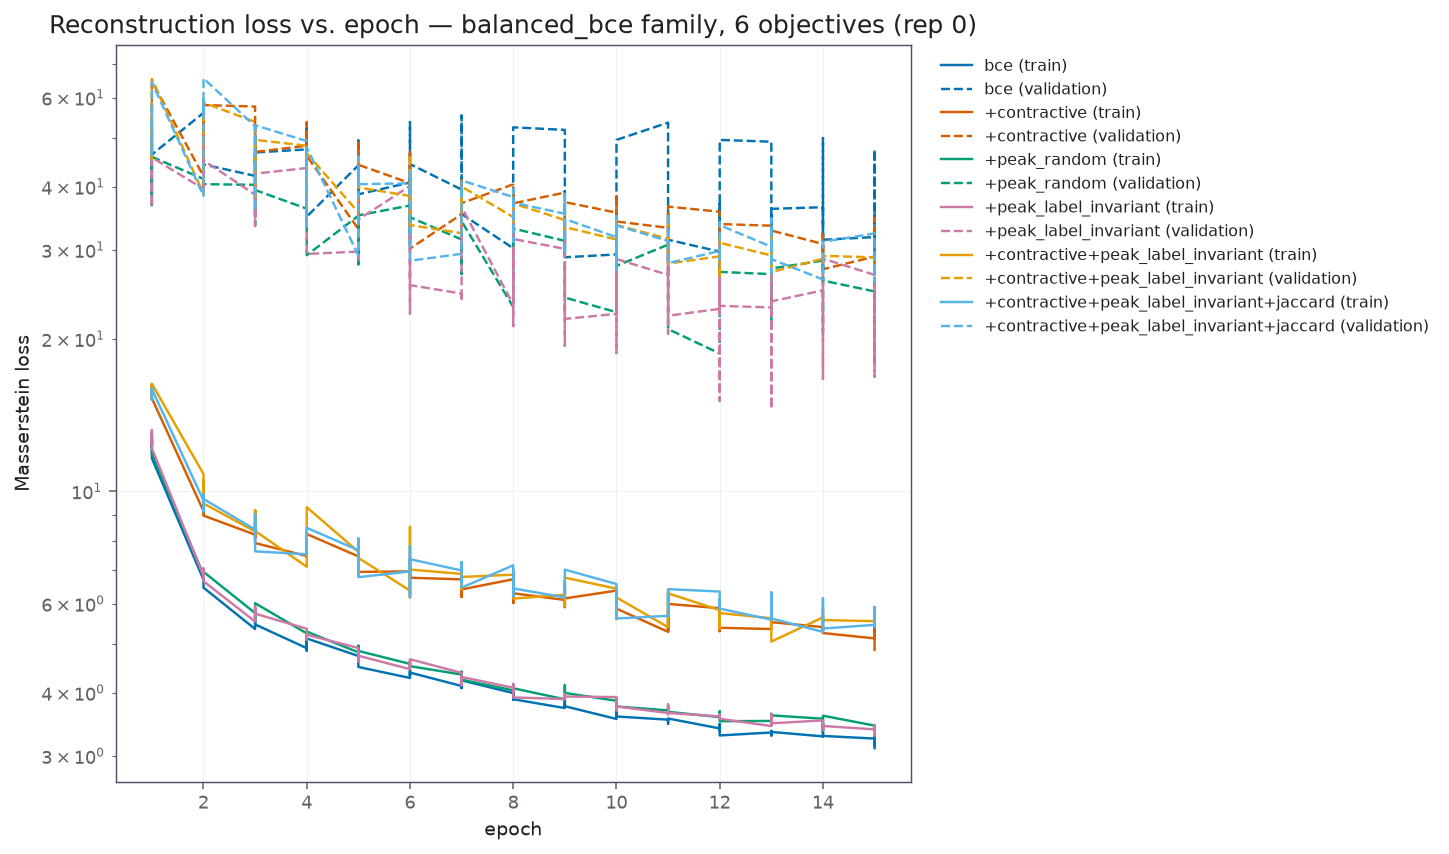

In [5]:
figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
for index, (key, label) in enumerate(MODEL_LABELS.items()):
    rows = epoch_frame[epoch_frame["objective"] == label].sort_values("epoch")
    color = theme.color_for_model(label, index)
    for value_key, linestyle, series_name in (("masserstein", "solid", "train"), ("validation_masserstein", "dashed", "validation")):
        ax.plot(
            rows["epoch"],
            rows[value_key],
            color=color,
            linestyle=linestyle,
            linewidth=theme.reconstruction_line_width,
            label=f"{label} ({series_name})",
        )
ax.set_yscale("log")
ax.set(
    xlabel="epoch",
    ylabel="Masserstein loss",
    title="Reconstruction loss vs. epoch — balanced_bce family, 6 objectives (rep 0)",
)
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=theme.legend_frame, fontsize=8)
figure.tight_layout()


**Caveat**: this is a single repetition (rep 0) per objective, read directly off
`history.json` — not yet averaged across `grid_0002`/`grid_0003`'s other 4 repetitions
each. Treat as a first look; if the pattern here looks close, it is worth repeating
with all 5 repetitions per objective before concluding anything from the aggregate
curve alone.


## Stage 1b — all 5 repetitions, with the seed-noise null check

`part_7` found that a `rep_0`-only geometric comparison between `bce` and the
contrastive variants did not survive a proper check against `bce`'s own
repetition-to-repetition spread. Same check here, on the actual metric this notebook
opened with (`validation_masserstein` at the best checkpoint, `part_1`'s
`best_checkpoint_masserstein` convention) — using all 5 repetitions per objective
directly from `history.json` (no model loading needed for this part), for the curated
`PAIRS` list defined in `Config` above: each single-term objective vs. `bce`, plus the
two chain links (`+peak_label_invariant` → `grid_0004`, `grid_0004` → `grid_0005`) that
answer this notebook's key new questions.


In [6]:
def best_checkpoint_masserstein(tasks, label: str) -> pd.DataFrame:
    rows = []
    for task in tasks:
        epoch_entries = [e for e in task.history if e.get("metrics", {}).get("epoch") is not None]
        if not epoch_entries:
            continue
        best_entry = min(epoch_entries, key=lambda entry: entry["metrics"].get("best_loss", float("inf")))
        rows.append({
            "objective": label,
            "task_id": task.task_id,
            "repetition": task.repetition,
            "validation_masserstein_at_best": best_entry["metrics"]["validation_masserstein"],
        })
    return pd.DataFrame(rows)


best_frame = pd.concat(
    [best_checkpoint_masserstein(tasks_by_key[key], MODEL_LABELS[key]) for key in MODEL_NAMES],
    ignore_index=True,
)
best_summary = best_frame.groupby("objective")["validation_masserstein_at_best"].agg(["mean", "std", "min", "max"])
best_summary


,mean,std,min,max
objective,,,,
+contractive,29.019184,1.986925,27.467661,32.208684
+contractive+peak_label_invariant,27.541070,1.159029,26.465141,29.024061
+contractive+peak_label_invariant+jaccard,27.823668,2.215413,25.963004,31.154329
+peak_label_invariant,21.380745,4.526854,14.568645,26.797846
+peak_random,23.869183,3.763145,17.749743,27.589625
bce,35.136815,7.563443,27.520899,47.456019


In [7]:
from itertools import combinations

null_rows = []
for key in MODEL_NAMES:
    values = best_frame.loc[best_frame["objective"] == MODEL_LABELS[key], "validation_masserstein_at_best"].to_numpy()
    reps = best_frame.loc[best_frame["objective"] == MODEL_LABELS[key], "repetition"].to_numpy()
    for (i, value_a), (j, value_b) in combinations(zip(reps, values), 2):
        null_rows.append({"objective": MODEL_LABELS[key], "rep_pair": f"{i}-{j}", "abs_diff": abs(value_a - value_b)})

null_frame = pd.DataFrame(null_rows)
null_summary = null_frame.groupby("objective")["abs_diff"].agg(["mean", "std", "min", "max"])

print("within-objective |rep_i - rep_j| null (validation Masserstein at best checkpoint):")
print(null_summary)
print()

comparison_rows = []
for left_key, right_key in PAIRS:
    left_label, right_label = MODEL_LABELS[left_key], MODEL_LABELS[right_key]
    pair_label = f"{left_label} vs {right_label}"
    between = abs(best_summary.loc[left_label, "mean"] - best_summary.loc[right_label, "mean"])
    larger_null = max(null_summary.loc[left_label, "mean"], null_summary.loc[right_label, "mean"])
    comparison_rows.append({
        "pair": pair_label,
        "between_mean": between,
        "larger_null_mean": larger_null,
        "signal_over_larger_null": between / larger_null,
    })
    print(f"between-objective |mean({left_label}) - mean({right_label})|: {between:.3f} (signal/null = {between / larger_null:.2f})")

comparison_frame = pd.DataFrame(comparison_rows)
comparison_frame


within-objective |rep_i - rep_j| null (validation Masserstein at best checkpoint):
                                               mean       std       min  \
objective                                                                 
+contractive                               2.322427  1.667356  0.030279   
+contractive+peak_label_invariant          1.409960  0.881105  0.100120   
+contractive+peak_label_invariant+jaccard  2.630363  1.794218  0.281153   
+peak_label_invariant                      5.506678  3.441787  0.412667   
+peak_random                               4.456204  3.066804  1.015678   
bce                                        8.925211  6.213958  1.627715   

                                                 max  
objective                                             
+contractive                                4.741022  
+contractive+peak_label_invariant           2.558919  
+contractive+peak_label_invariant+jaccard   5.191325  
+peak_label_invariant                    

,pair,between_mean,larger_null_mean,signal_over_larger_null
0,bce vs +contractive,6.117631,8.925211,0.685433
1,bce vs +peak_random,11.267633,8.925211,1.262450
2,bce vs +peak_label_invariant,13.756070,8.925211,1.541260
3,+peak_label_invariant vs +contractive+peak_lab...,6.160325,5.506678,1.118701
4,+contractive+peak_label_invariant vs +contract...,0.282598,2.630363,0.107437
5,bce vs +contractive+peak_label_invariant,7.595745,8.925211,0.851044
6,bce vs +contractive+peak_label_invariant+jaccard,7.313147,8.925211,0.819381


## Load all six models

All six share one dataset/split (verified in `config.json` before this notebook was
written — see the intro), so `train`/`test` from any one of them indexes the same
pixels as the others.


In [8]:
SCRATCH_WORKSPACE_ROOT = Path("/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace")
SCRATCH_WORKSPACE_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not SCRATCH_WORKSPACE_ROOT.is_symlink():
    SCRATCH_WORKSPACE_ROOT.symlink_to(WORKSPACE.resolve())

wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

# All six objectives share one image/binner/annotation-store/dataset context —
# only the model weights differ (verified in the intro above). `load_configuration`
# unconditionally re-resolves the raw imzML reader (measured ~38-40s) on every call;
# `models_manager.load_model` swaps only the model architecture/weights and leaves
# context untouched (measured ~0.04s) — pay the full cost once, then use the
# lightweight swap for the remaining five objectives.
models = {}
devices = {}
for index, (key, model_name) in enumerate(MODEL_NAMES.items()):
    if index == 0:
        wrapper.load_configuration(model_name=model_name)
        models[key] = wrapper.active_model
    else:
        models[key] = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
    models[key].eval()
    devices[key] = next(models[key].parameters()).device

shared_partitions = wrapper.active_dataset.create_partitions()
partitions_by_key = {key: shared_partitions for key in MODEL_NAMES}

mass_axis = wrapper.active_context.binner.GetXAxis()
for key in MODEL_NAMES:
    print(f"{key}: train={len(partitions_by_key[key].train)} test={len(partitions_by_key[key].test)}")


2026-08-26 12:44:34,244 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-26 12:44:34,245 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-26 12:44:34,246 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-26 12:44:34,247 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-26 12:44:34,248 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-26 12:45:11,885 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


2026-08-26 12:45:11,891 | INFO     | msi_autoencoder_wrapper.core.mixins.active_context.active_context_mixin:113 | Successfully bound active context memory maps for: kidney


2026-08-26 12:45:30,508 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:203 | Mapped annotation index: retained_rows=420649 retained_entries=10495756 coordinate_system=binner.


2026-08-26 12:45:30,675 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:275 | Selected 420649/421955 source spectra after annotation policies.


bce: train=33553 test=4023
contractive: train=33553 test=4023
peak_random: train=33553 test=4023
peak_label_invariant: train=33553 test=4023
grid4: train=33553 test=4023
grid5: train=33553 test=4023


## Pick example spectra and plot reconstructions

Two views per spectrum, both sharing the `input - reconstruction` residual convention
(positive = under-predicted, negative = over-predicted):

- **Full range**: one row per objective, each showing that objective's reconstruction
  against the input alone, stacked on a shared m/z axis (signal and residual y-limits
  matched across rows so the rows are directly comparable). Many objectives overlaid on
  one axis is hard to read at the full m/z range — this replaces that with one panel
  pair per variant.
- **Zoom (±15 m/z around the spectrum's own highest-intensity bin)**: kept as a single
  multi-variant overlay, since at this resolution overlaid curves stay legible (with
  extra transparency added, `secondary_alpha=0.50`/`residual_alpha=0.75` set in
  `Config` above).


In [9]:
rng = np.random.default_rng(RANDOM_SEED)
reference_partitions = partitions_by_key["bce"]
example_ids_by_split = {
    split_name: rng.choice(
        reference_partitions.manifest.assignments[split_name], size=EXAMPLE_COUNT, replace=False
    )
    for split_name in ("train", "test")
}


def reconstruct_all(spectrum_id: int, split_name: str) -> tuple[np.ndarray, dict[str, np.ndarray], dict[str, float]]:
    reconstructions = {}
    original = None
    for key in MODEL_NAMES:
        partitions = partitions_by_key[key]
        index = list(partitions.manifest.assignments[split_name]).index(spectrum_id)
        item = getattr(partitions, split_name)[index]
        spectrum = item[1].unsqueeze(0).float().to(devices[key])
        with torch.no_grad():
            reconstructions[MODEL_LABELS[key]] = models[key](spectrum)["reconstruction"][0].cpu().numpy()
        if original is None:
            original = item[1].numpy()

    # Per-spectrum Masserstein cost for every variant, reusing the same metric
    # Stage 1/1b report in aggregate (SpectrumMasserstein via masserstein_distances).
    labels = list(reconstructions)
    inputs_batch = np.tile(original[None, :], (len(labels), 1))
    outputs_batch = np.stack([reconstructions[label] for label in labels])
    costs = masserstein_distances(inputs_batch, outputs_batch, mass_axis, device="cpu")
    masserstein_costs = dict(zip(labels, costs.tolist()))

    return original, reconstructions, masserstein_costs


def plot_pixel_full_range(
    spectrum_id: int, split_name: str, original: np.ndarray, reconstructions: dict, masserstein_costs: dict
) -> None:
    n_variants = len(reconstructions)
    figure, axes = plt.subplots(
        2 * n_variants,
        1,
        figsize=(14.0, 3.1 * n_variants),
        dpi=theme.figure_dpi,
        sharex=True,
        gridspec_kw={"height_ratios": [2.0, 1.0] * n_variants},
    )
    signal_max = max([original.max()] + [r.max() for r in reconstructions.values()]) * 1.1
    residual_max = max(np.abs(original - r).max() for r in reconstructions.values()) * 1.1

    for row, (label, reconstruction) in enumerate(reconstructions.items()):
        signal_axis, residual_axis = axes[2 * row], axes[2 * row + 1]
        plot_spectrum_comparison(
            mass_axis, original, {label: reconstruction}, axes=(signal_axis, residual_axis), theme=theme,
        )
        signal_axis.set_ylim(0, signal_max)
        residual_axis.set_ylim(-residual_max, residual_max)
        if row < n_variants - 1:
            residual_axis.set_xlabel("")
        signal_axis.text(
            0.99, 0.92, f"Masserstein = {masserstein_costs[label]:.3f}",
            transform=signal_axis.transAxes, ha="right", va="top", fontsize=9,
        )

    axes[0].set_title(f"spectrum {spectrum_id} — {split_name} (full range, one panel pair per variant)", loc="left")
    figure.tight_layout()


def plot_pixel_zoom(
    spectrum_id: int, split_name: str, original: np.ndarray, reconstructions: dict, masserstein_costs: dict
) -> None:
    zoom_figure, zoom_axes = plot_spectrum_comparison(mass_axis, original, reconstructions, theme=theme)
    zoom_figure.set_size_inches(14.0, 7.5)

    peak_index = int(np.argmax(original))
    peak_mz = float(mass_axis[peak_index])
    window_low, window_high = peak_mz - ZOOM_HALF_WIDTH_MZ, peak_mz + ZOOM_HALF_WIDTH_MZ
    window_mask = (mass_axis >= window_low) & (mass_axis <= window_high)

    zoom_axes[0].set_xlim(window_low, window_high)
    zoom_axes[1].set_xlim(window_low, window_high)
    signal_max = max([original[window_mask].max()] + [r[window_mask].max() for r in reconstructions.values()])
    zoom_axes[0].set_ylim(0, signal_max * 1.1)
    residual_max = max(np.abs(original - r)[window_mask].max() for r in reconstructions.values())
    zoom_axes[1].set_ylim(-residual_max * 1.1, residual_max * 1.1)
    zoom_axes[0].set_title(f"spectrum {spectrum_id} — {split_name} (zoom, m/z {peak_mz:.1f} \u00b1 {ZOOM_HALF_WIDTH_MZ:.0f})", loc="left")

    # Append the full-spectrum Masserstein cost to each legend entry — the zoom
    # view only shows a small m/z window, so the cost itself must come from the
    # full spectrum (computed once in reconstruct_all) to stay meaningful.
    for axis in (zoom_axes[0], zoom_axes[1]):
        legend = axis.get_legend()
        if legend is None:
            continue
        texts = legend.get_texts()
        offset = len(texts) - len(reconstructions)  # signal legend also has "input" first
        for text, label in zip(texts[offset:], reconstructions):
            text.set_text(f"{text.get_text()} (M={masserstein_costs[label]:.3f})")


def plot_pixel(spectrum_id: int, split_name: str) -> None:
    original, reconstructions, masserstein_costs = reconstruct_all(spectrum_id, split_name)
    plot_pixel_full_range(spectrum_id, split_name, original, reconstructions, masserstein_costs)
    plot_pixel_zoom(spectrum_id, split_name, original, reconstructions, masserstein_costs)


### Training pixels


/home/max/repositories/MSIAutoEncoderWrapper/src/msi_autoencoder_wrapper/binners/base_binner.py:46: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  intensity_tensor = torch.as_tensor(intensities, dtype=self.dtype)


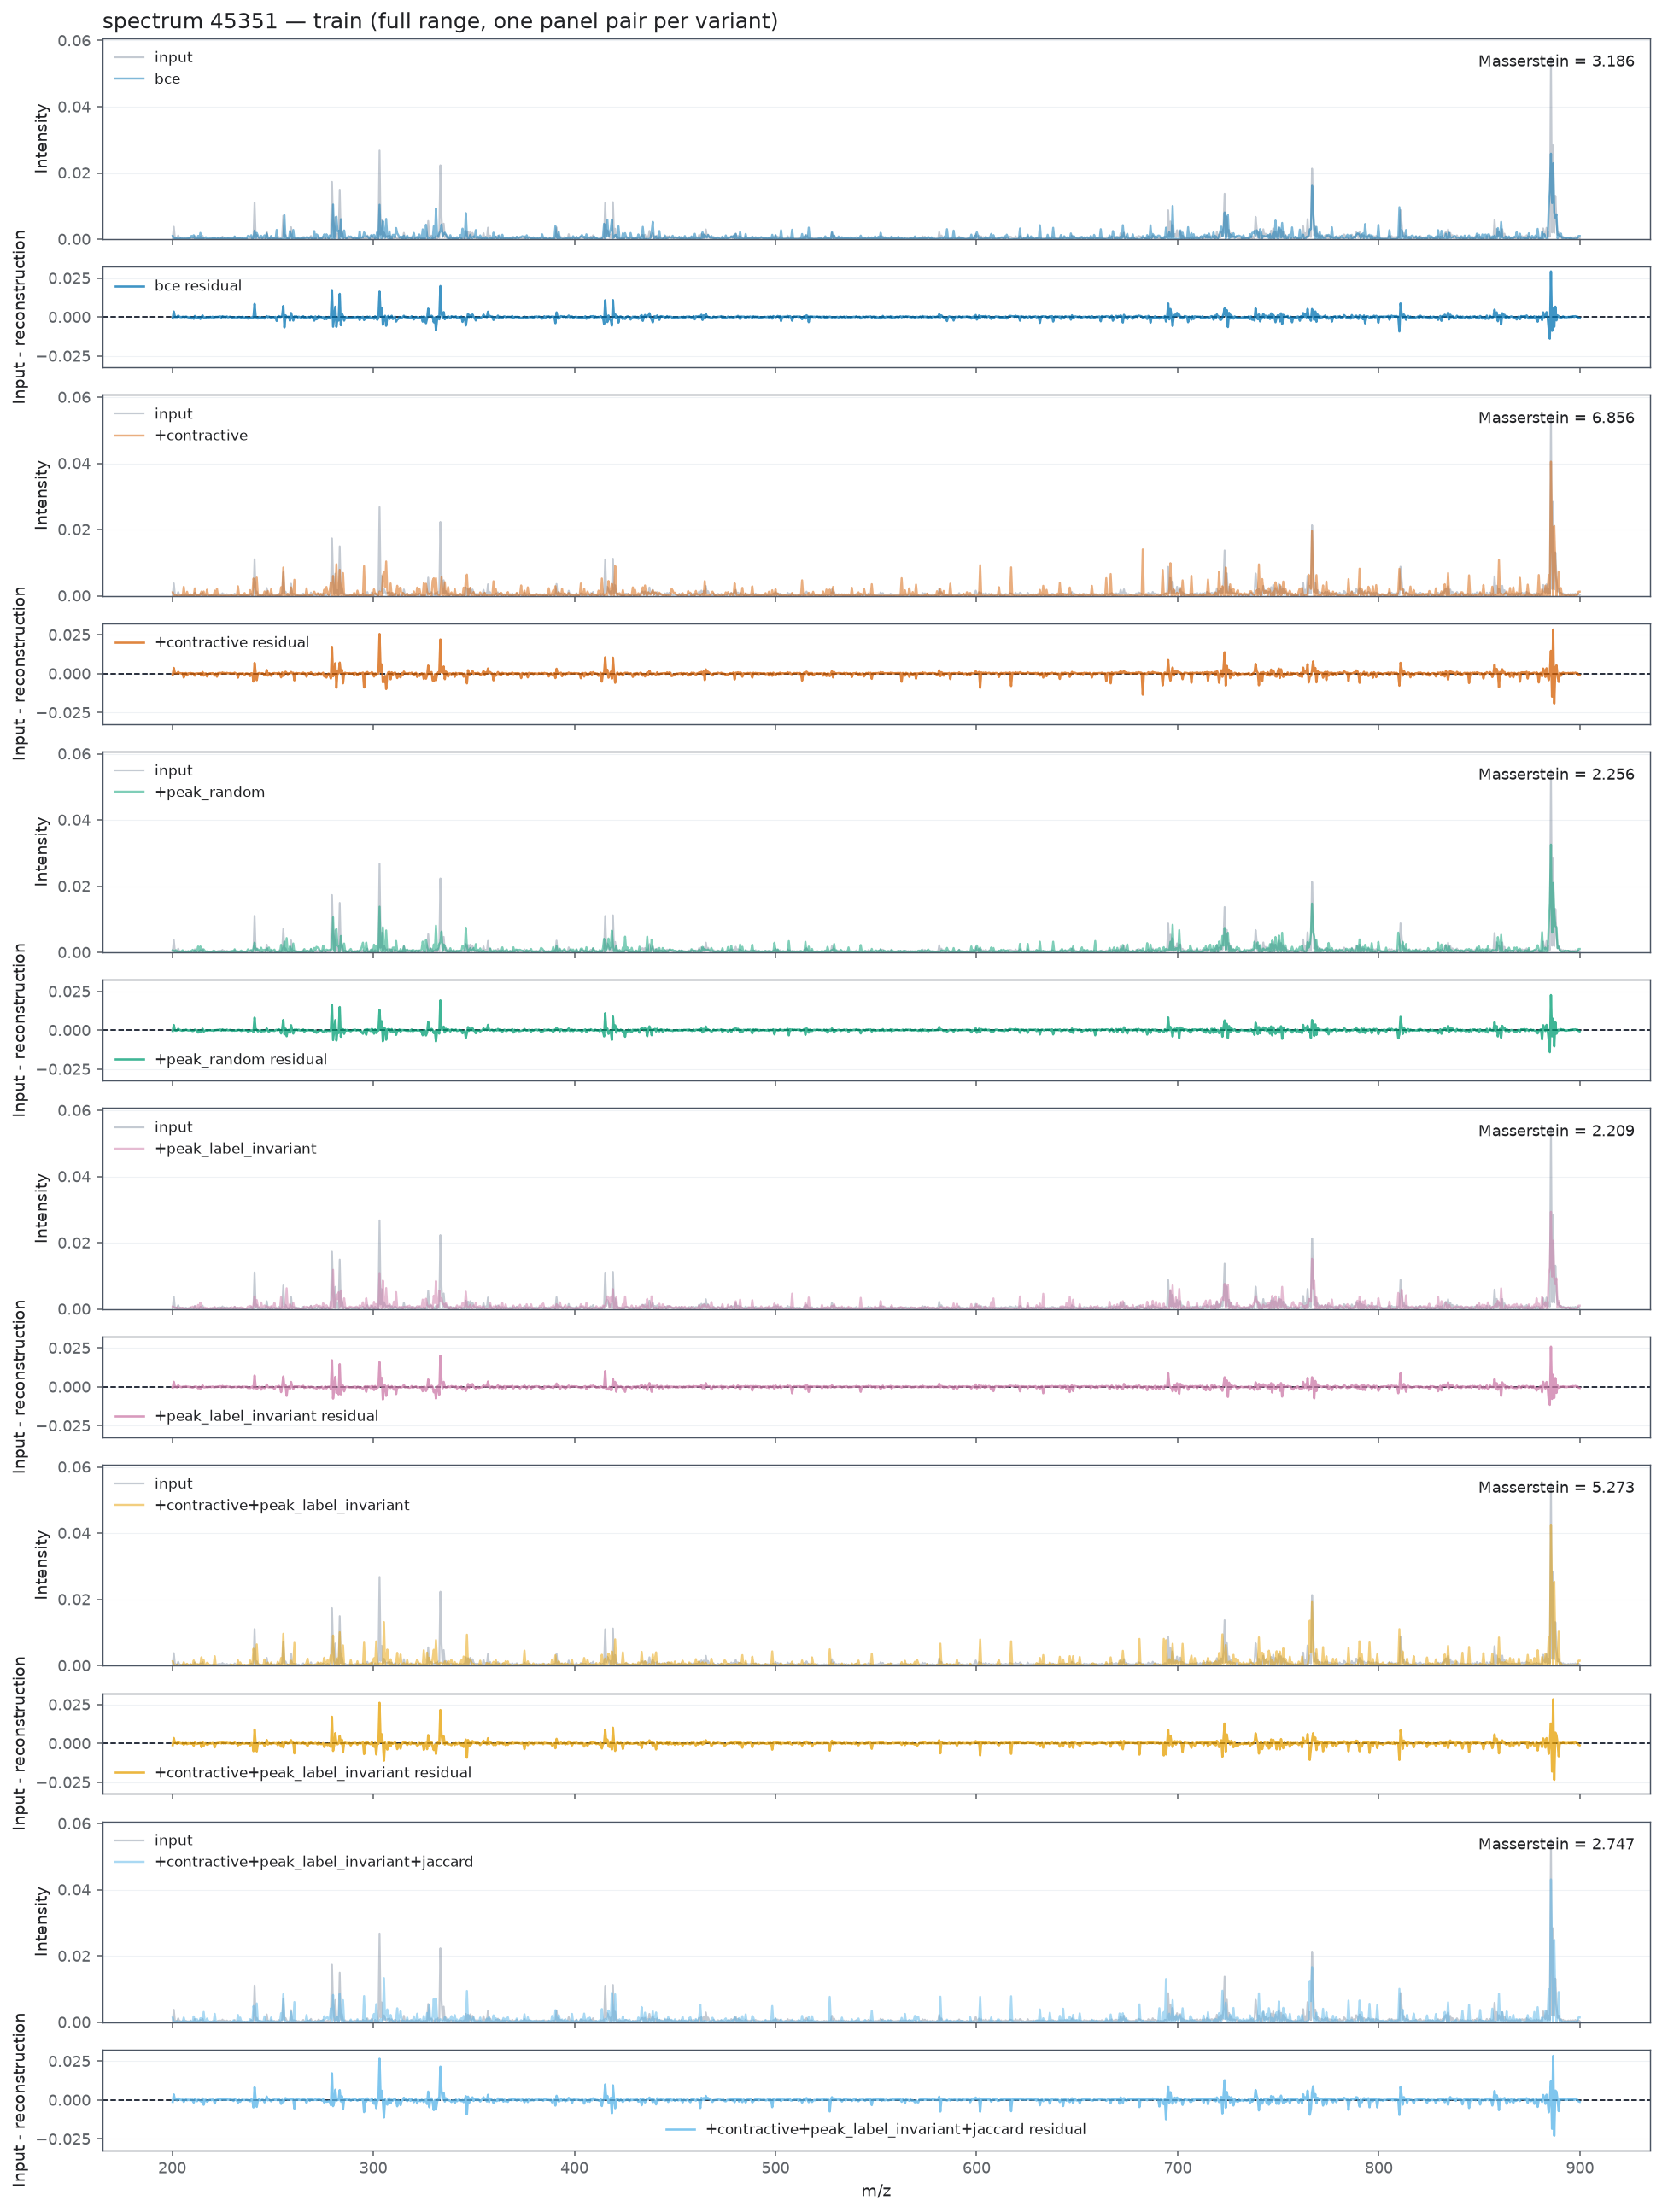

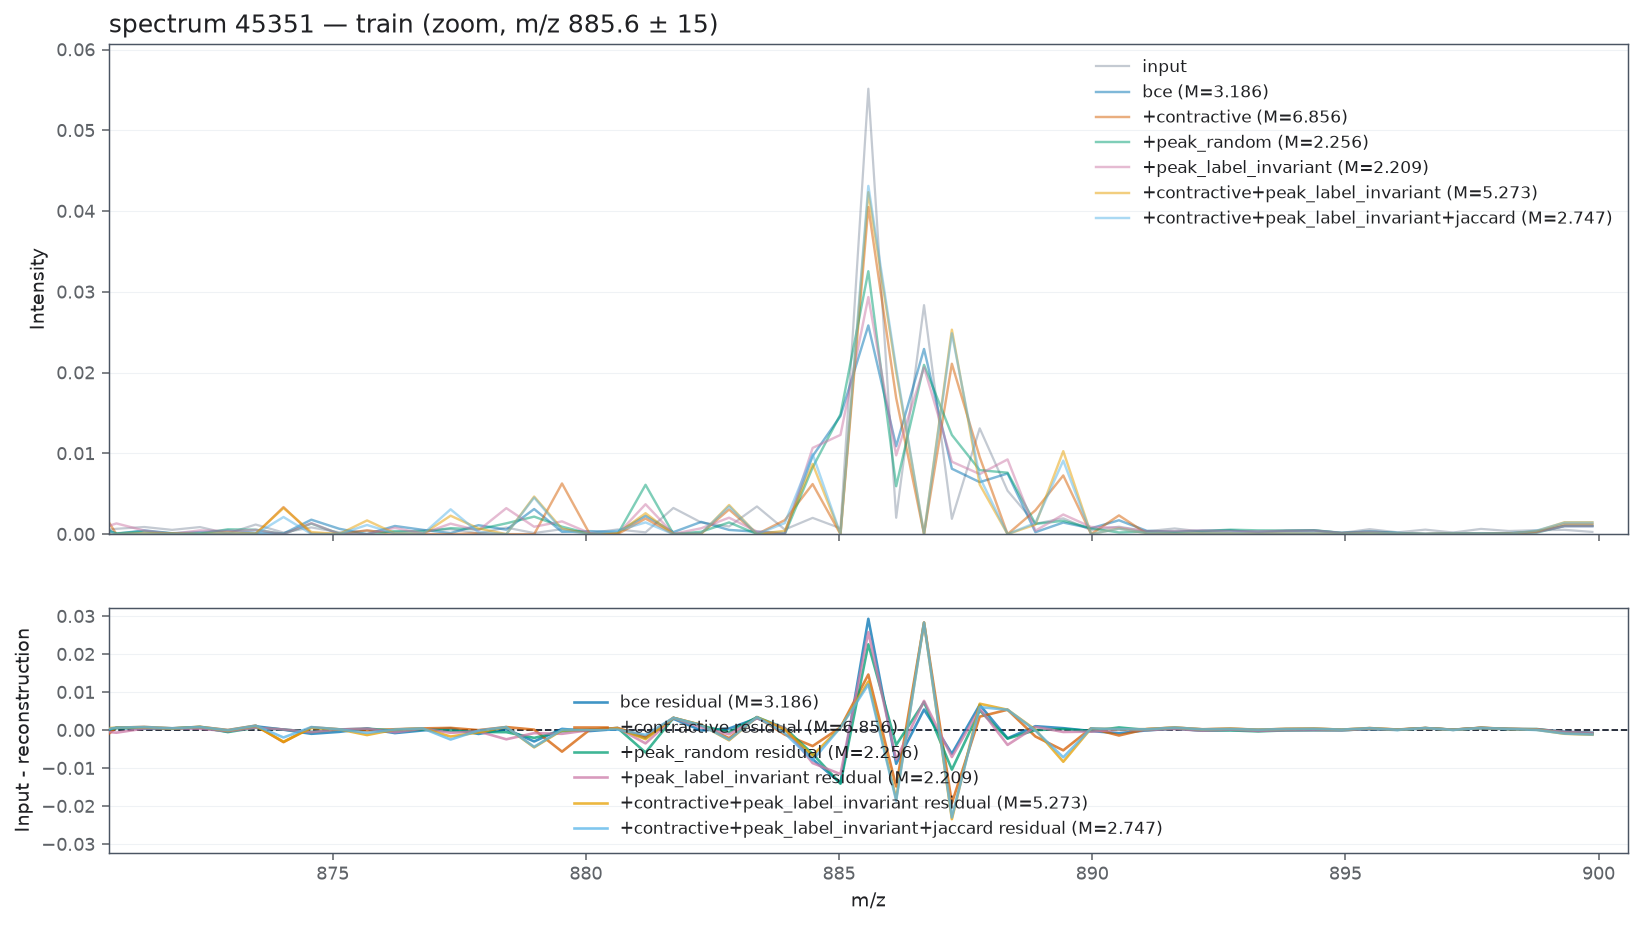

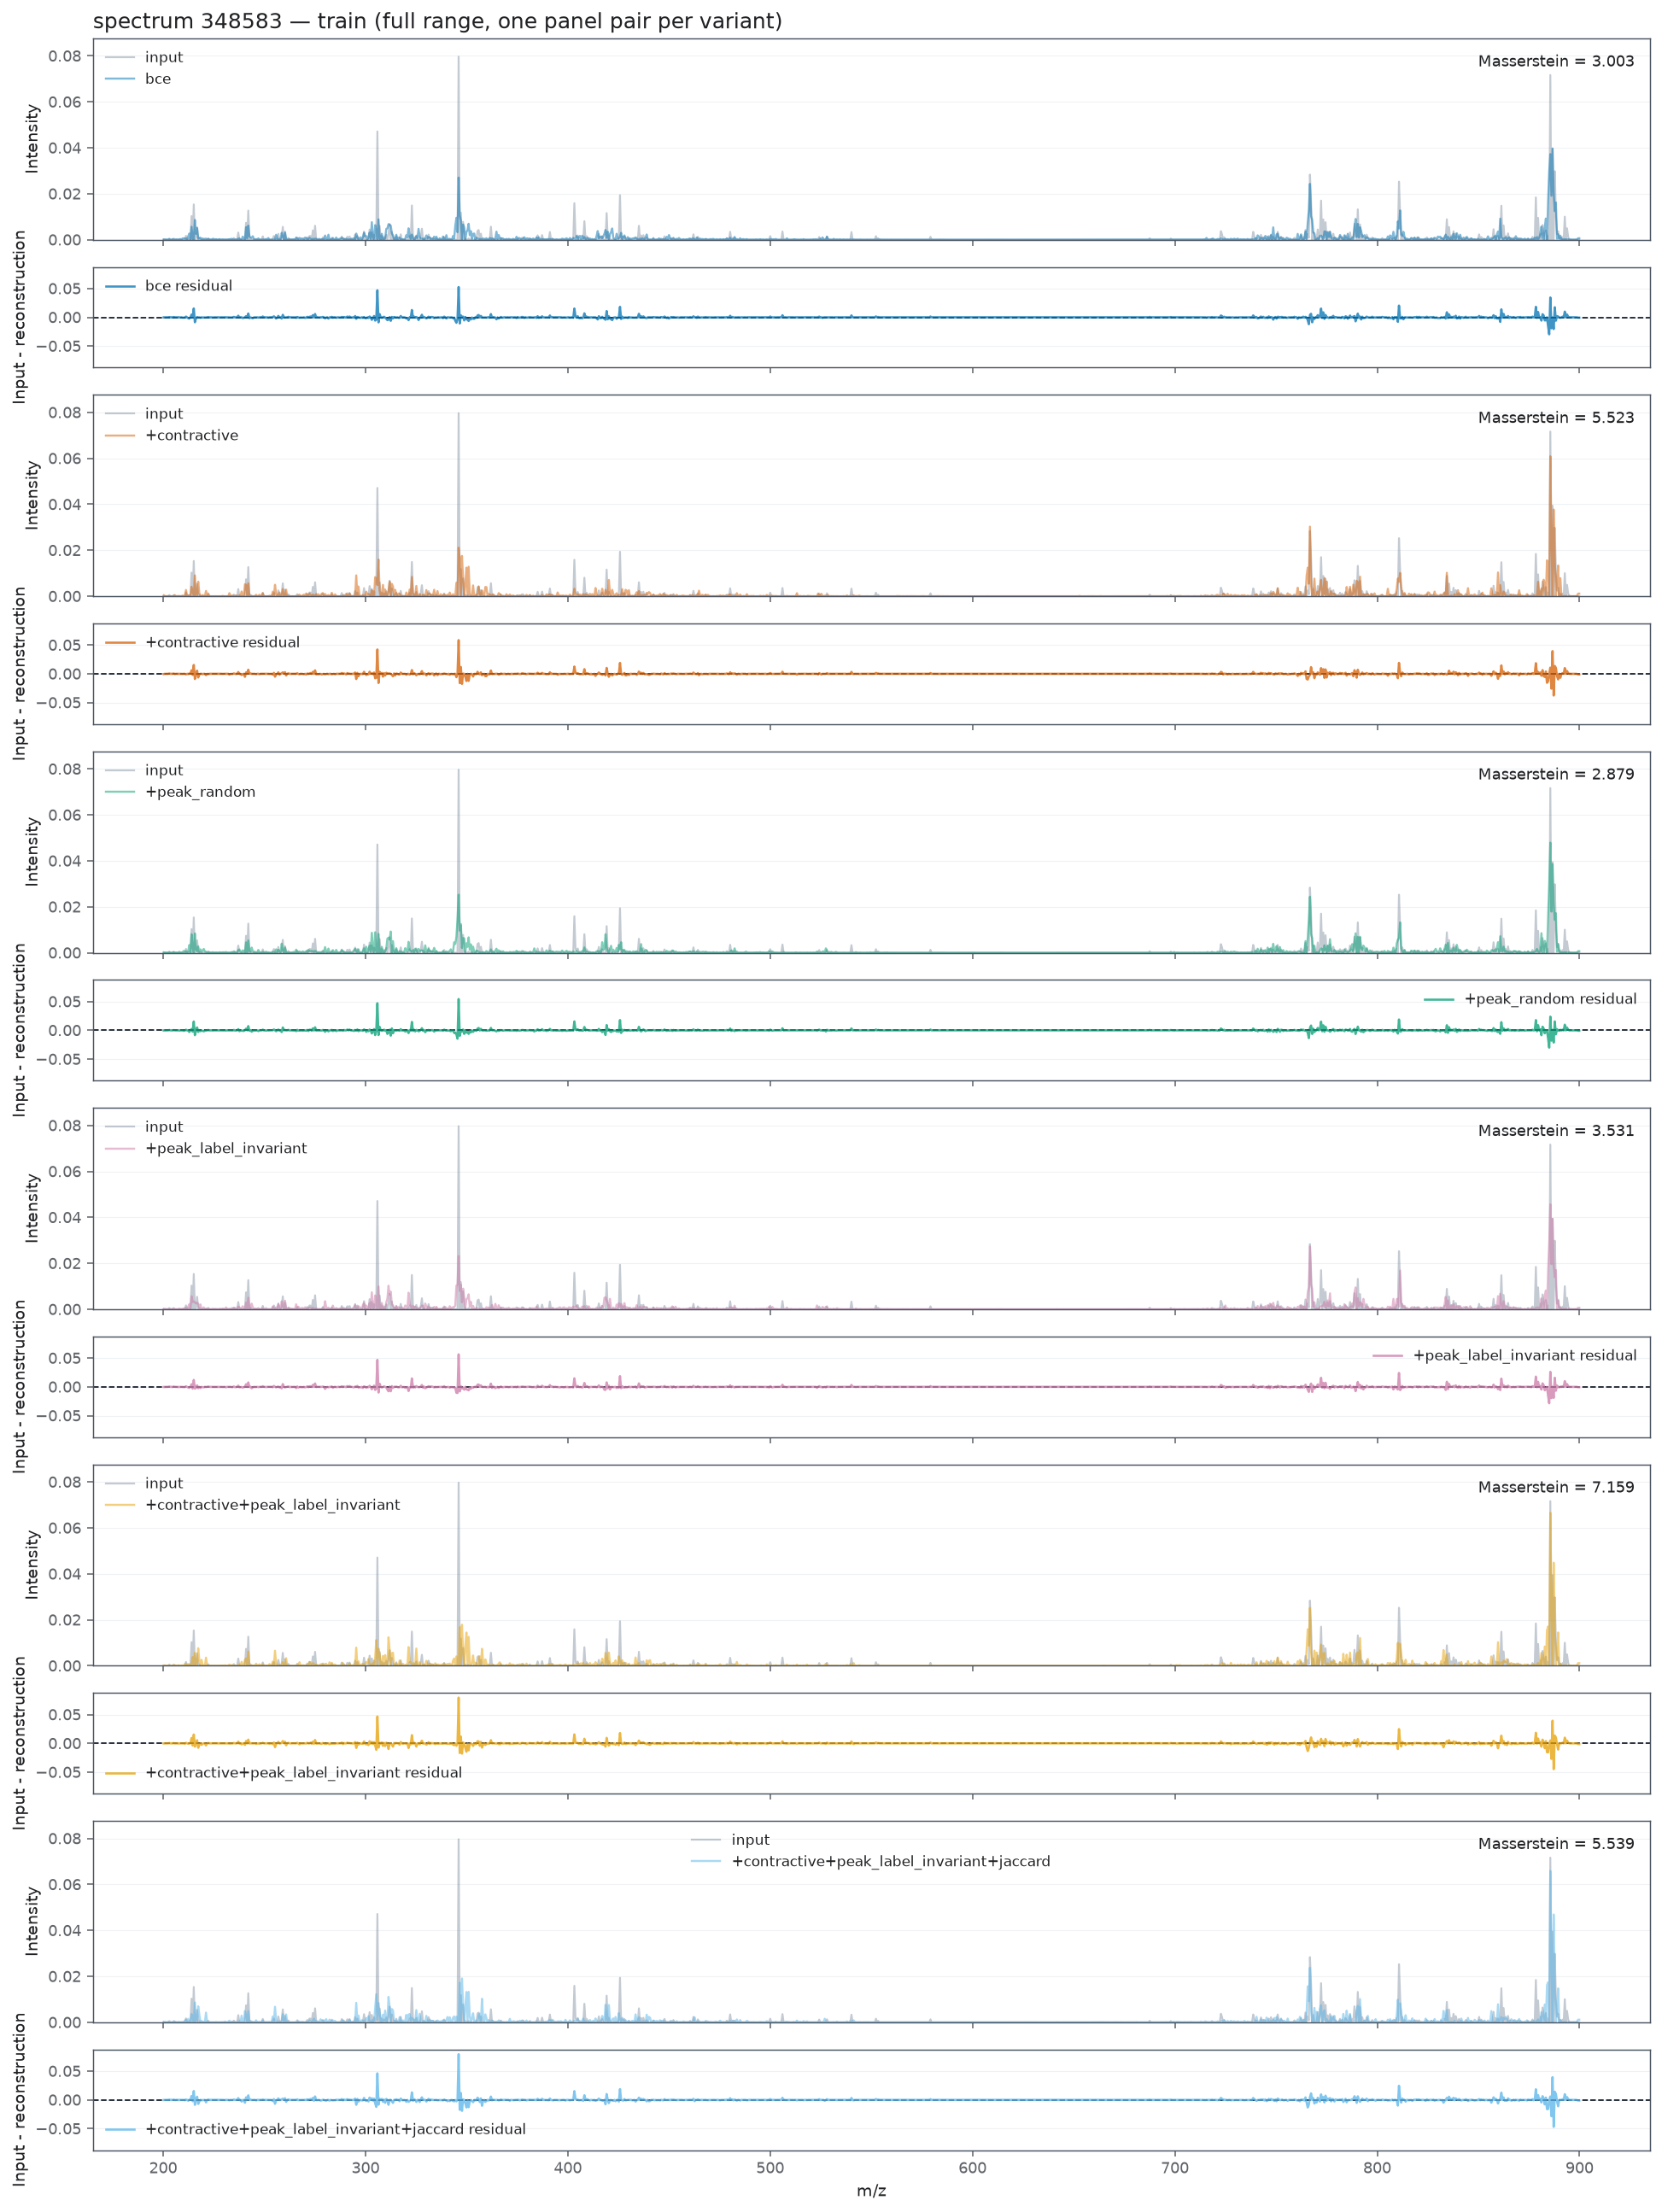

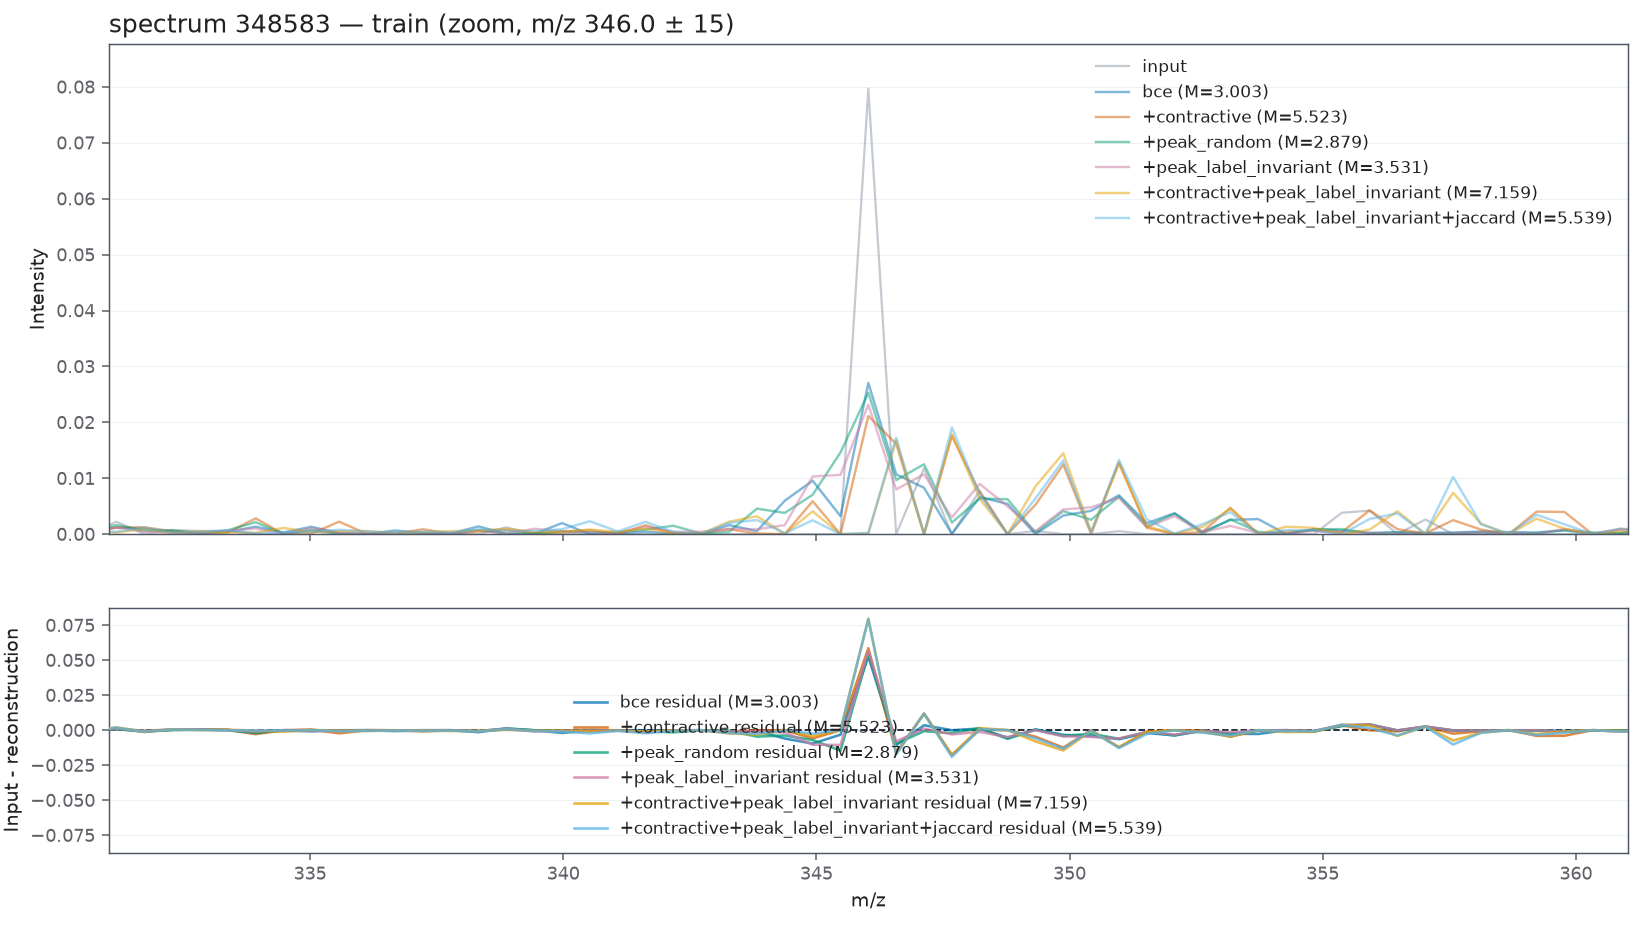

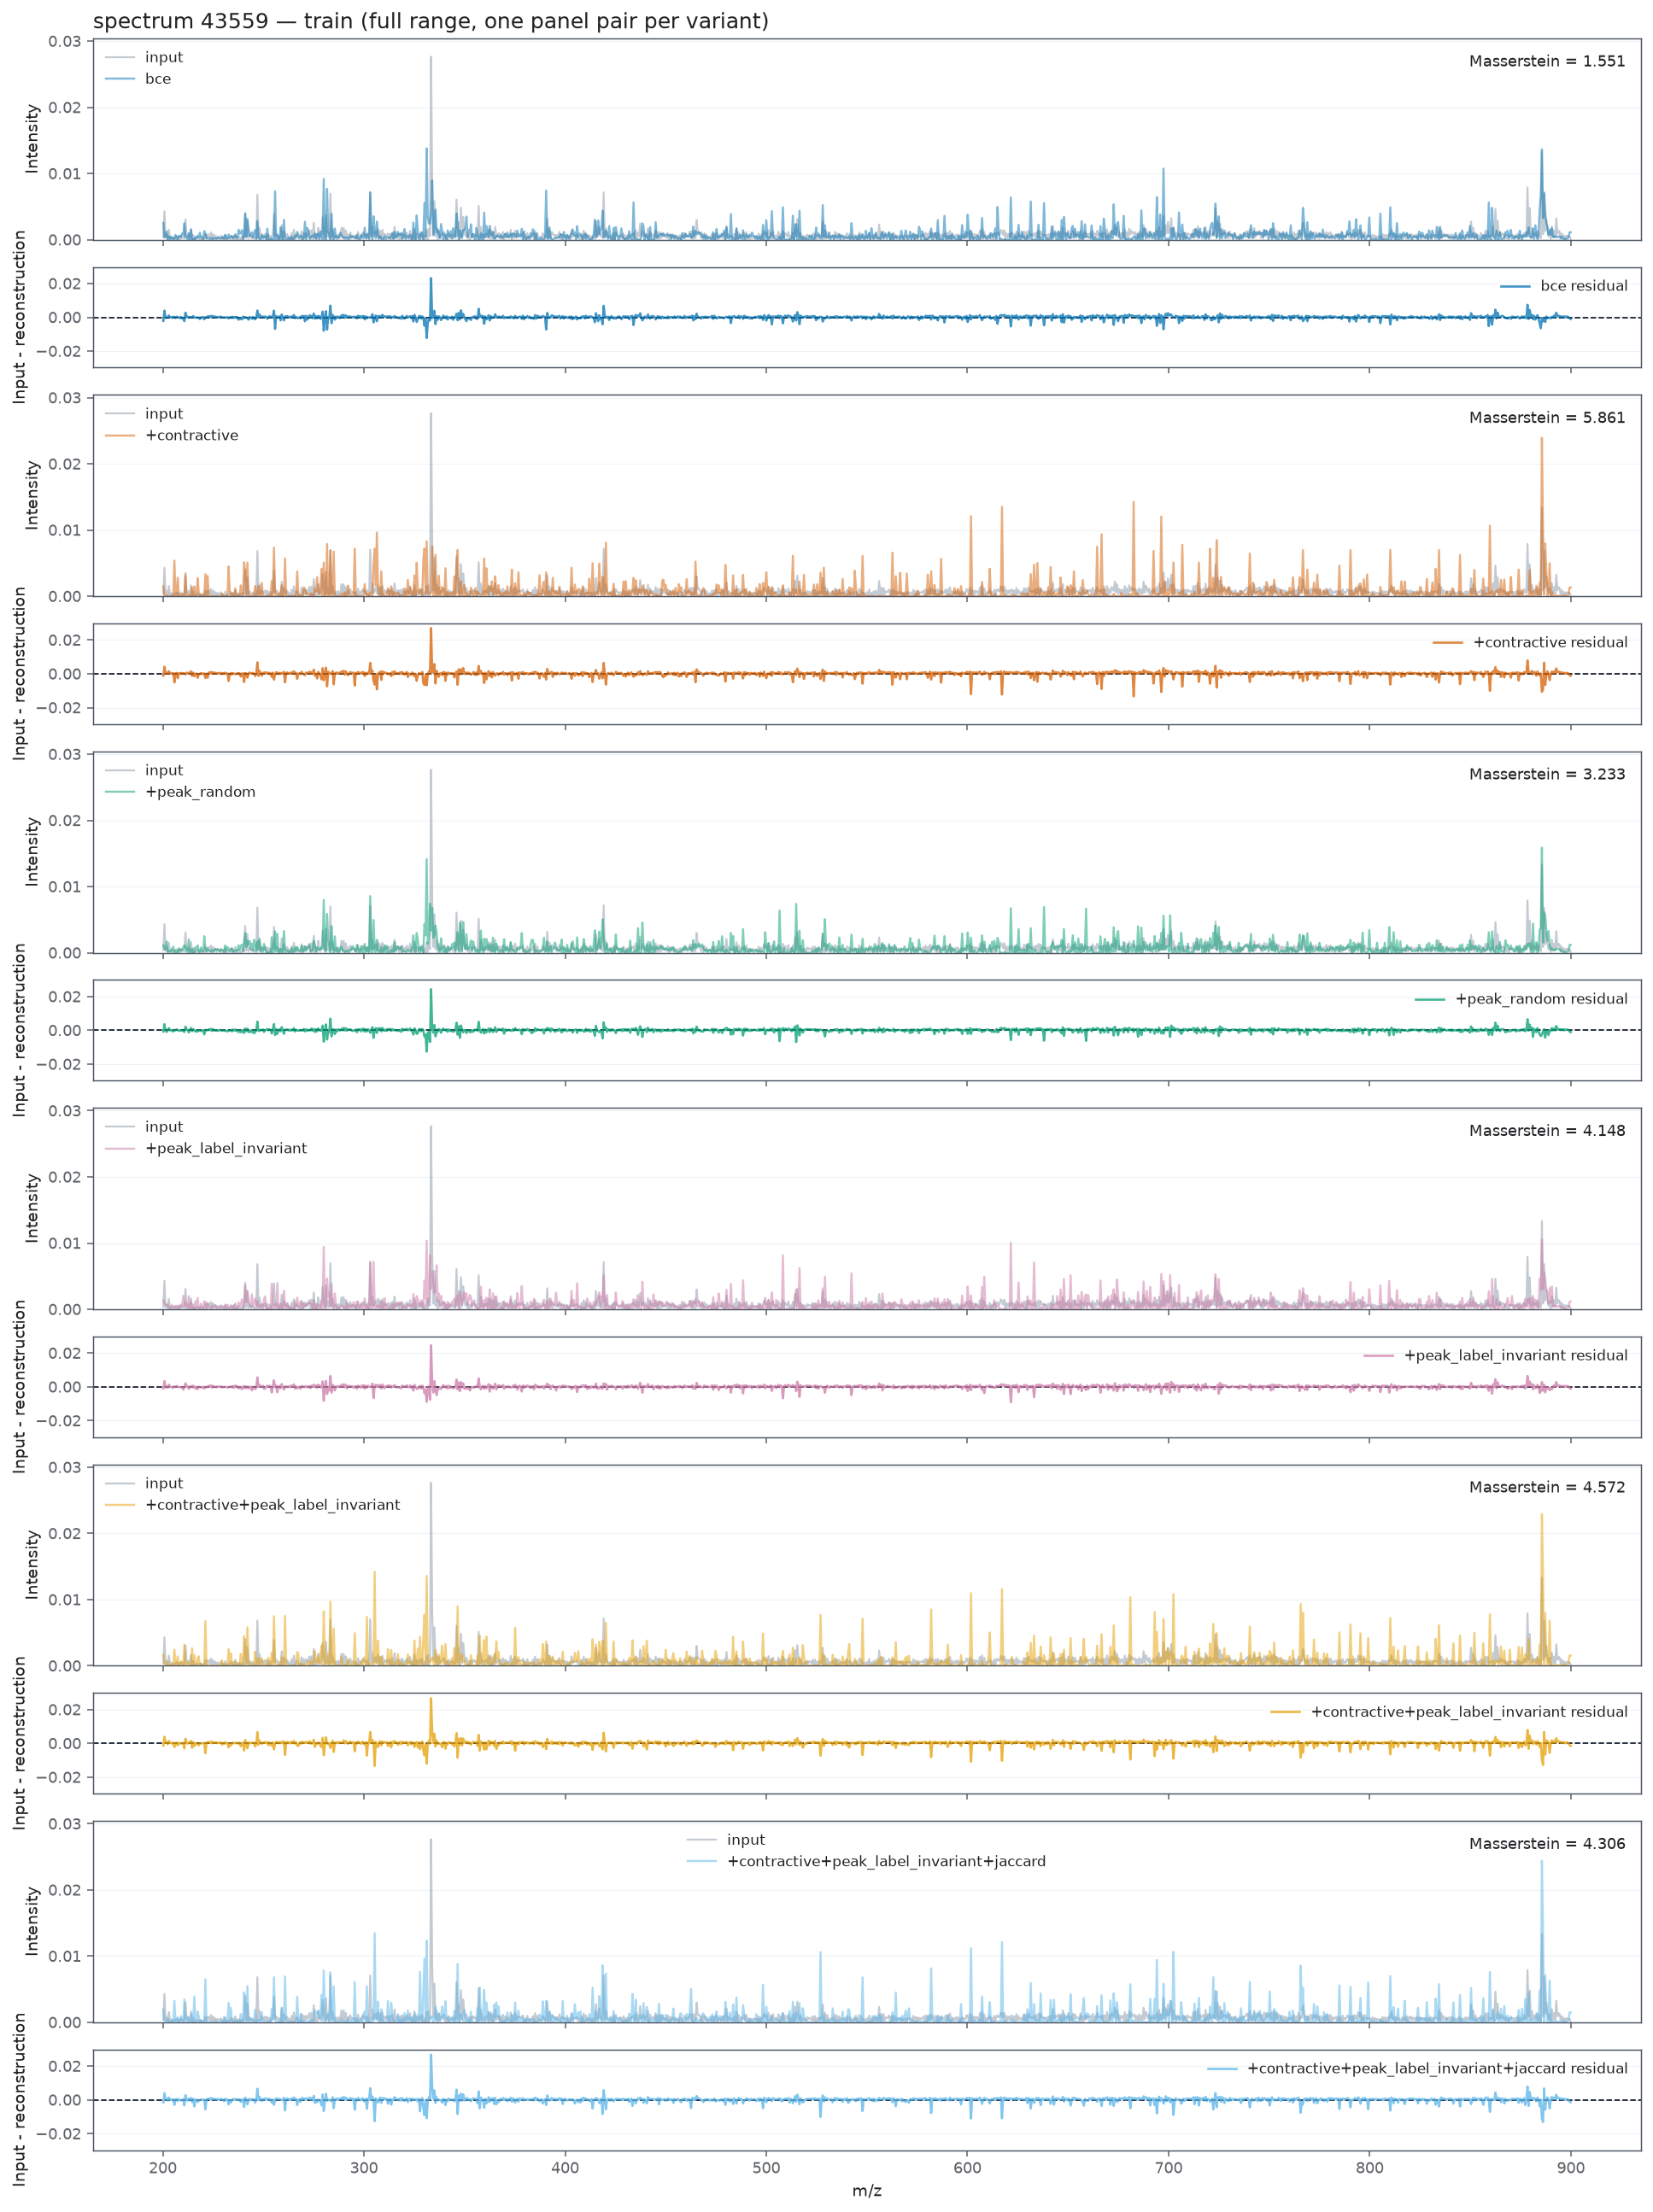

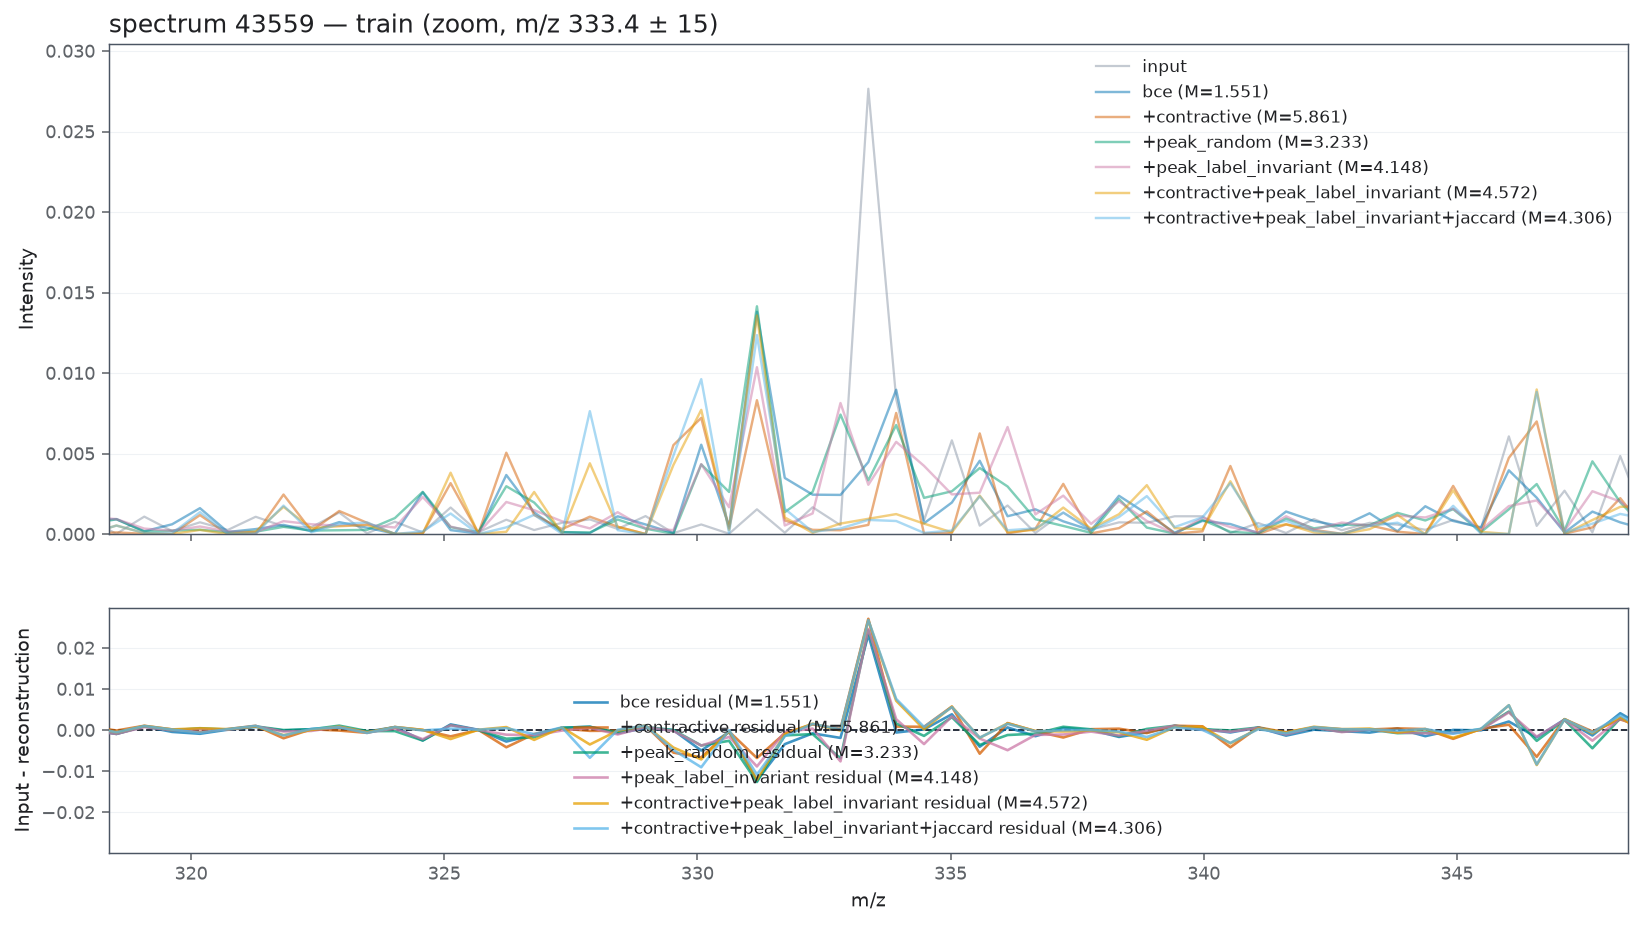

In [10]:
for spectrum_id in example_ids_by_split["train"]:
    plot_pixel(int(spectrum_id), "train")


### Held-out (test) pixels


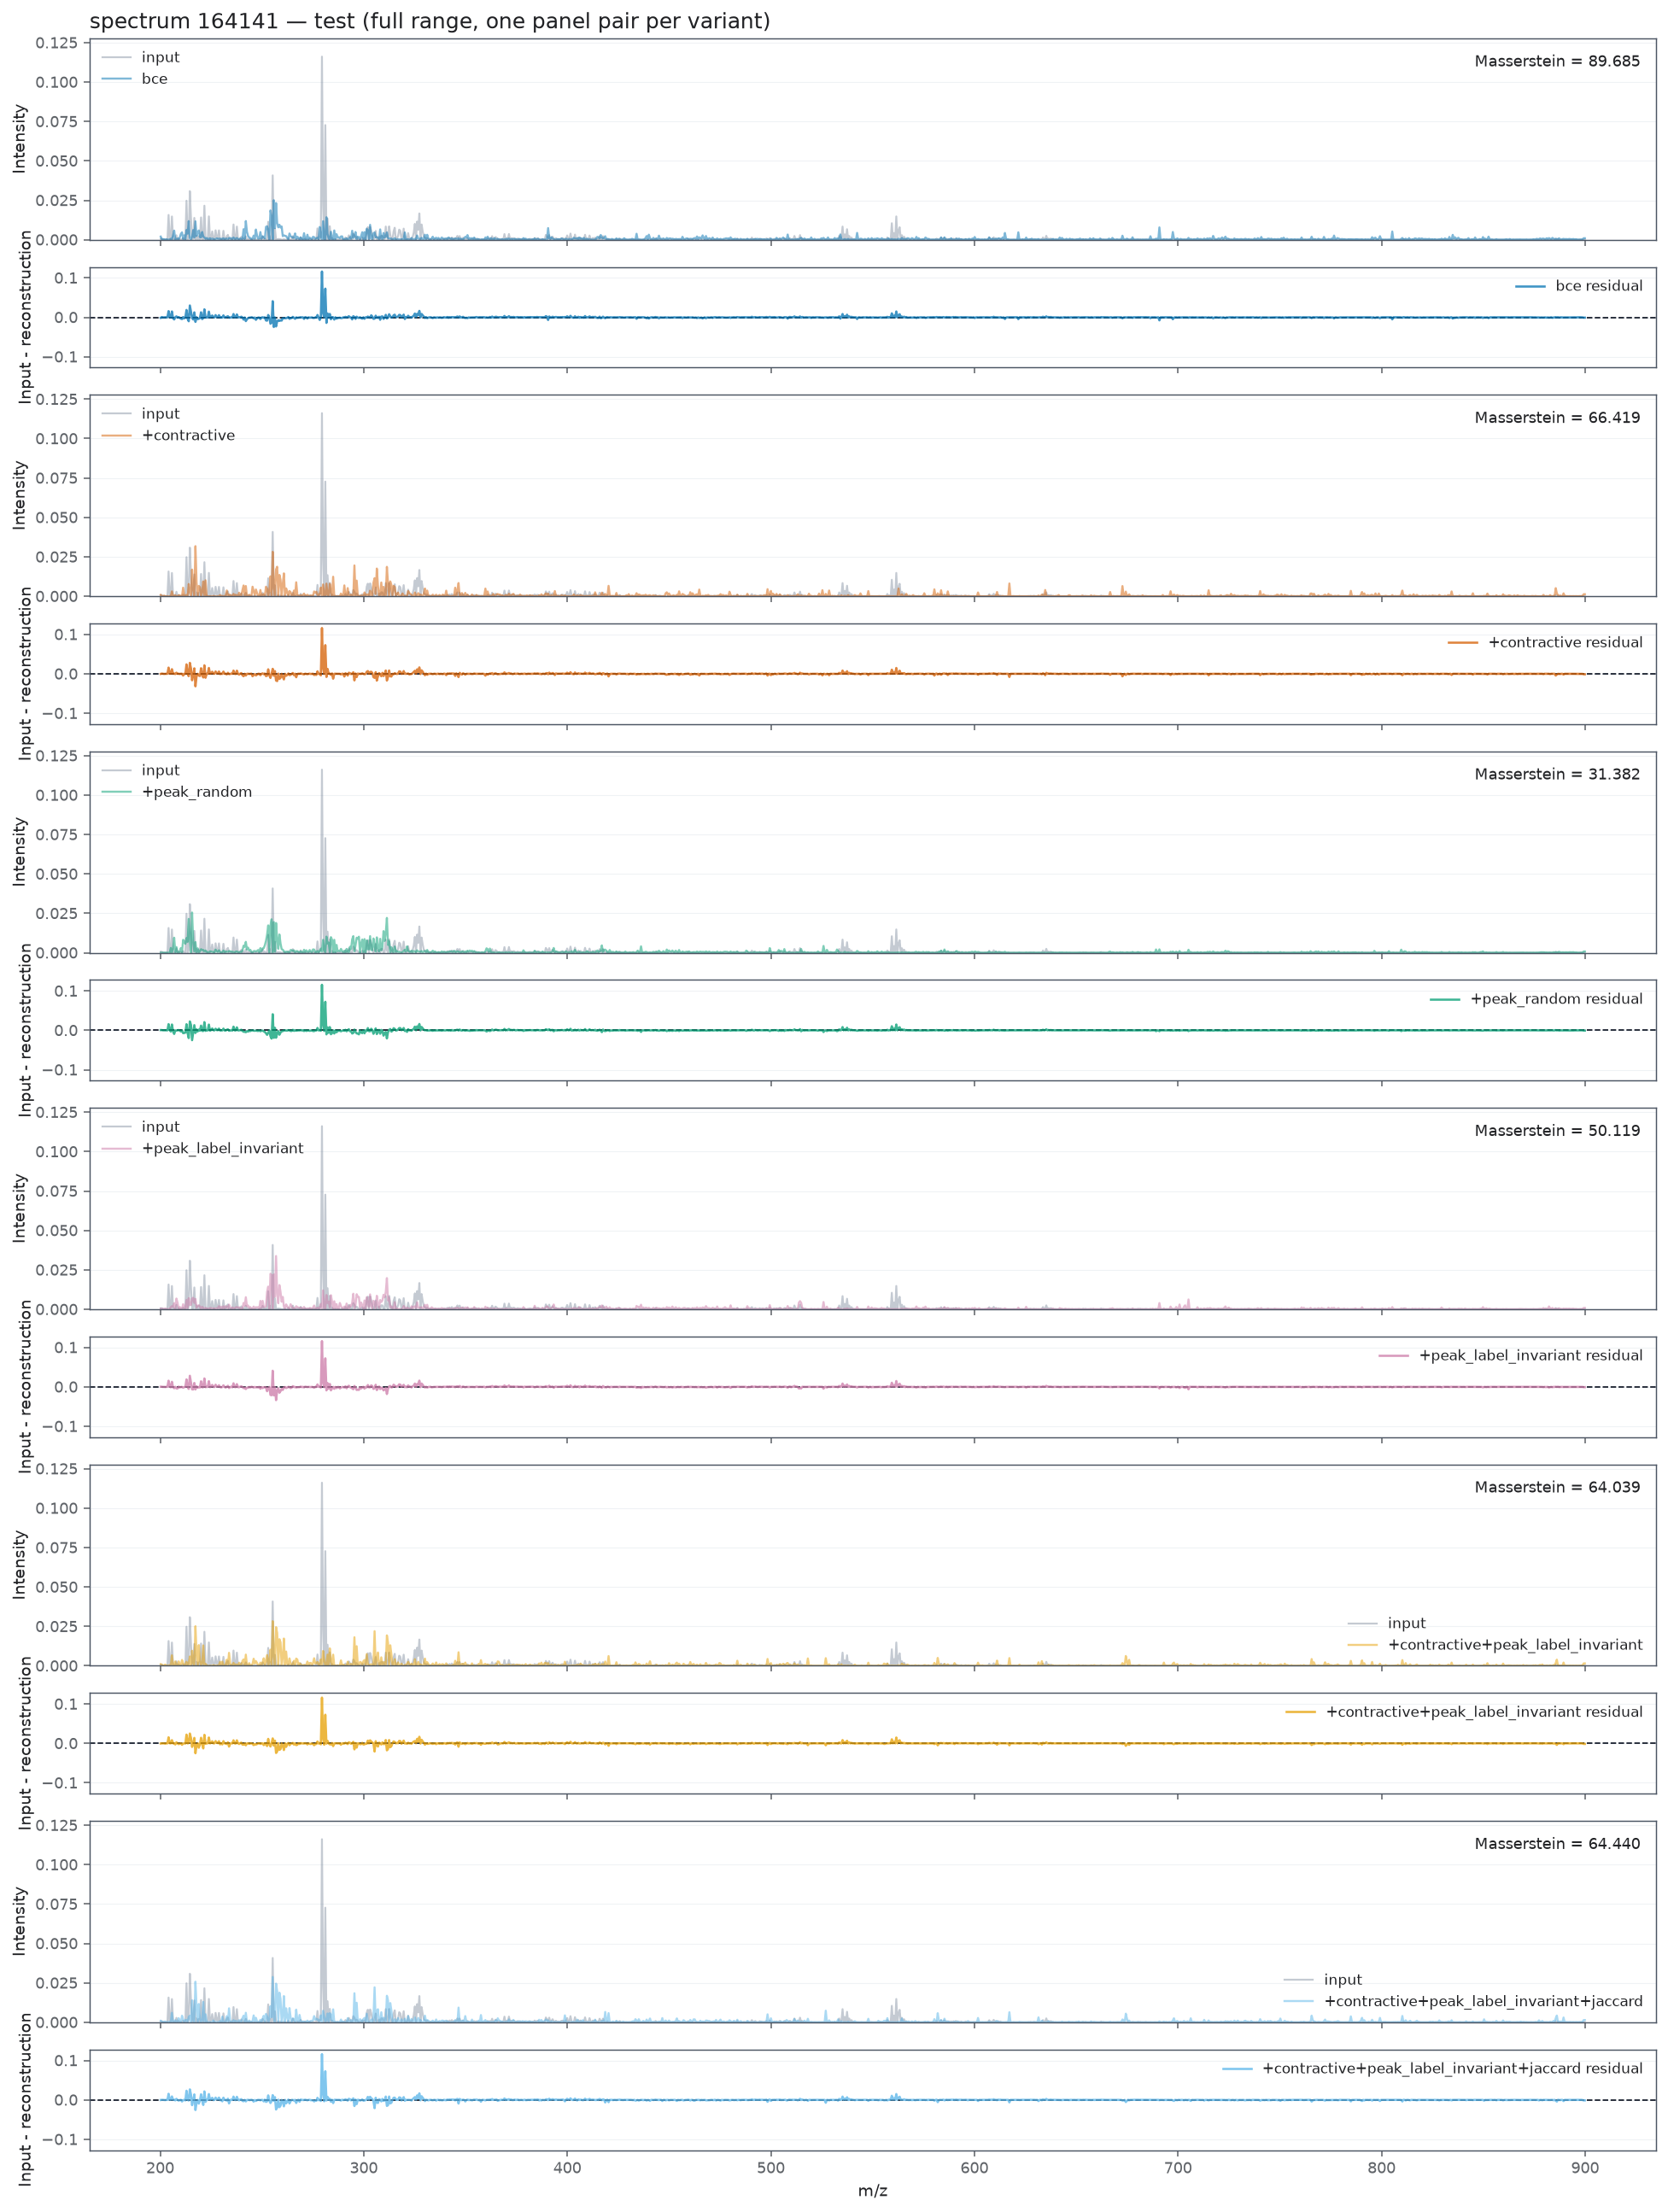

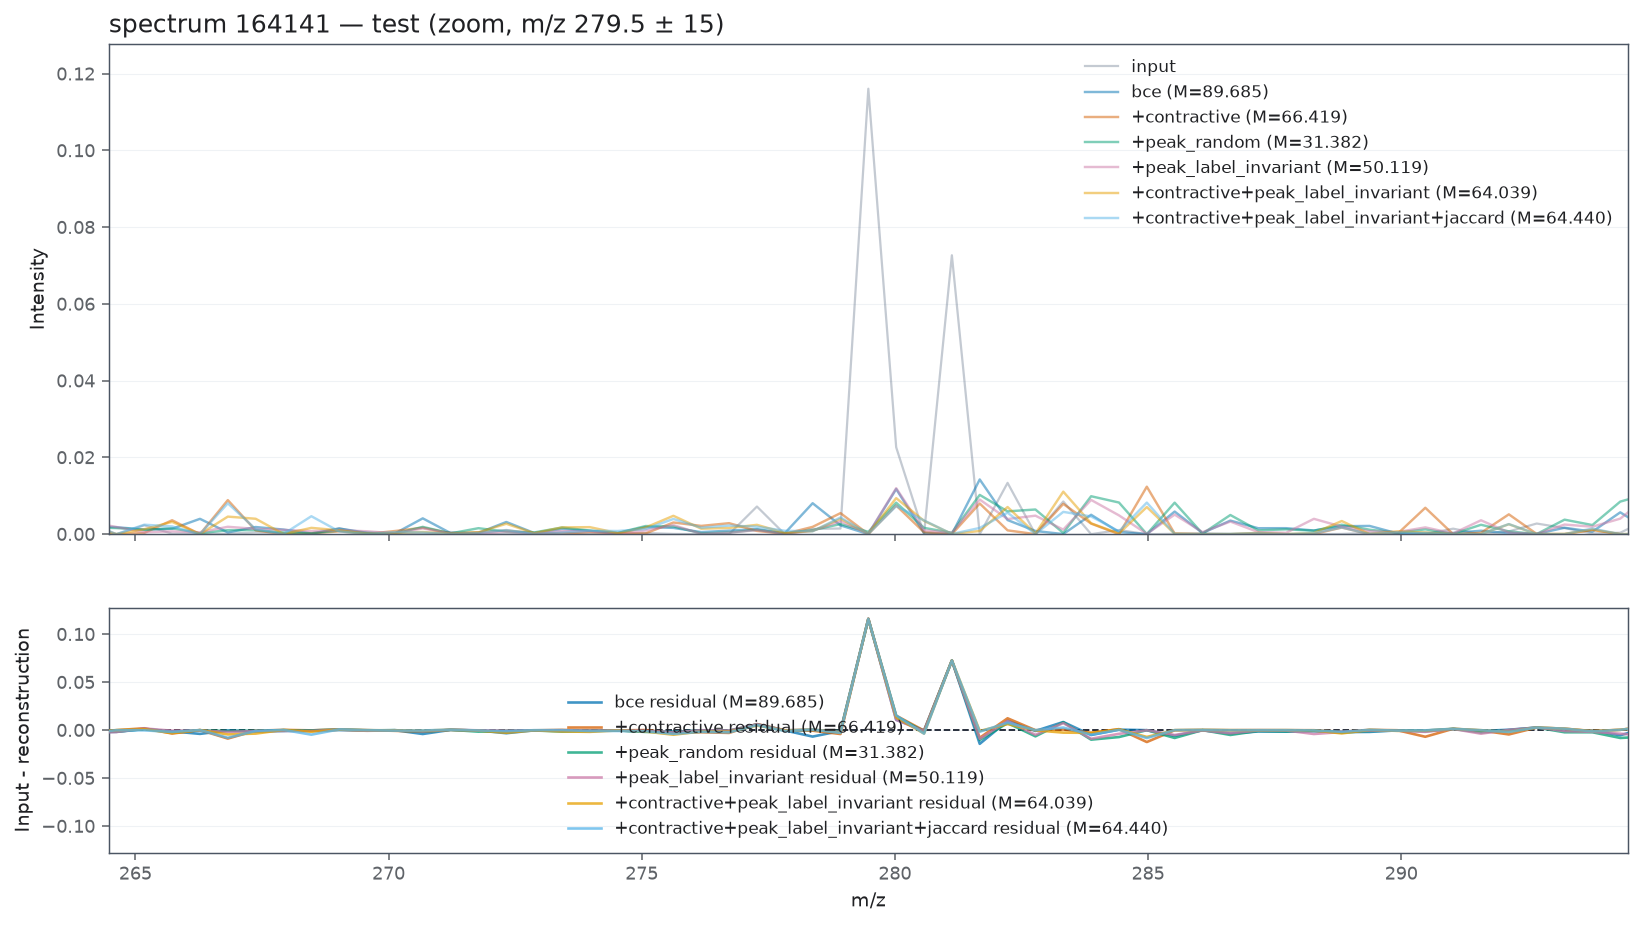

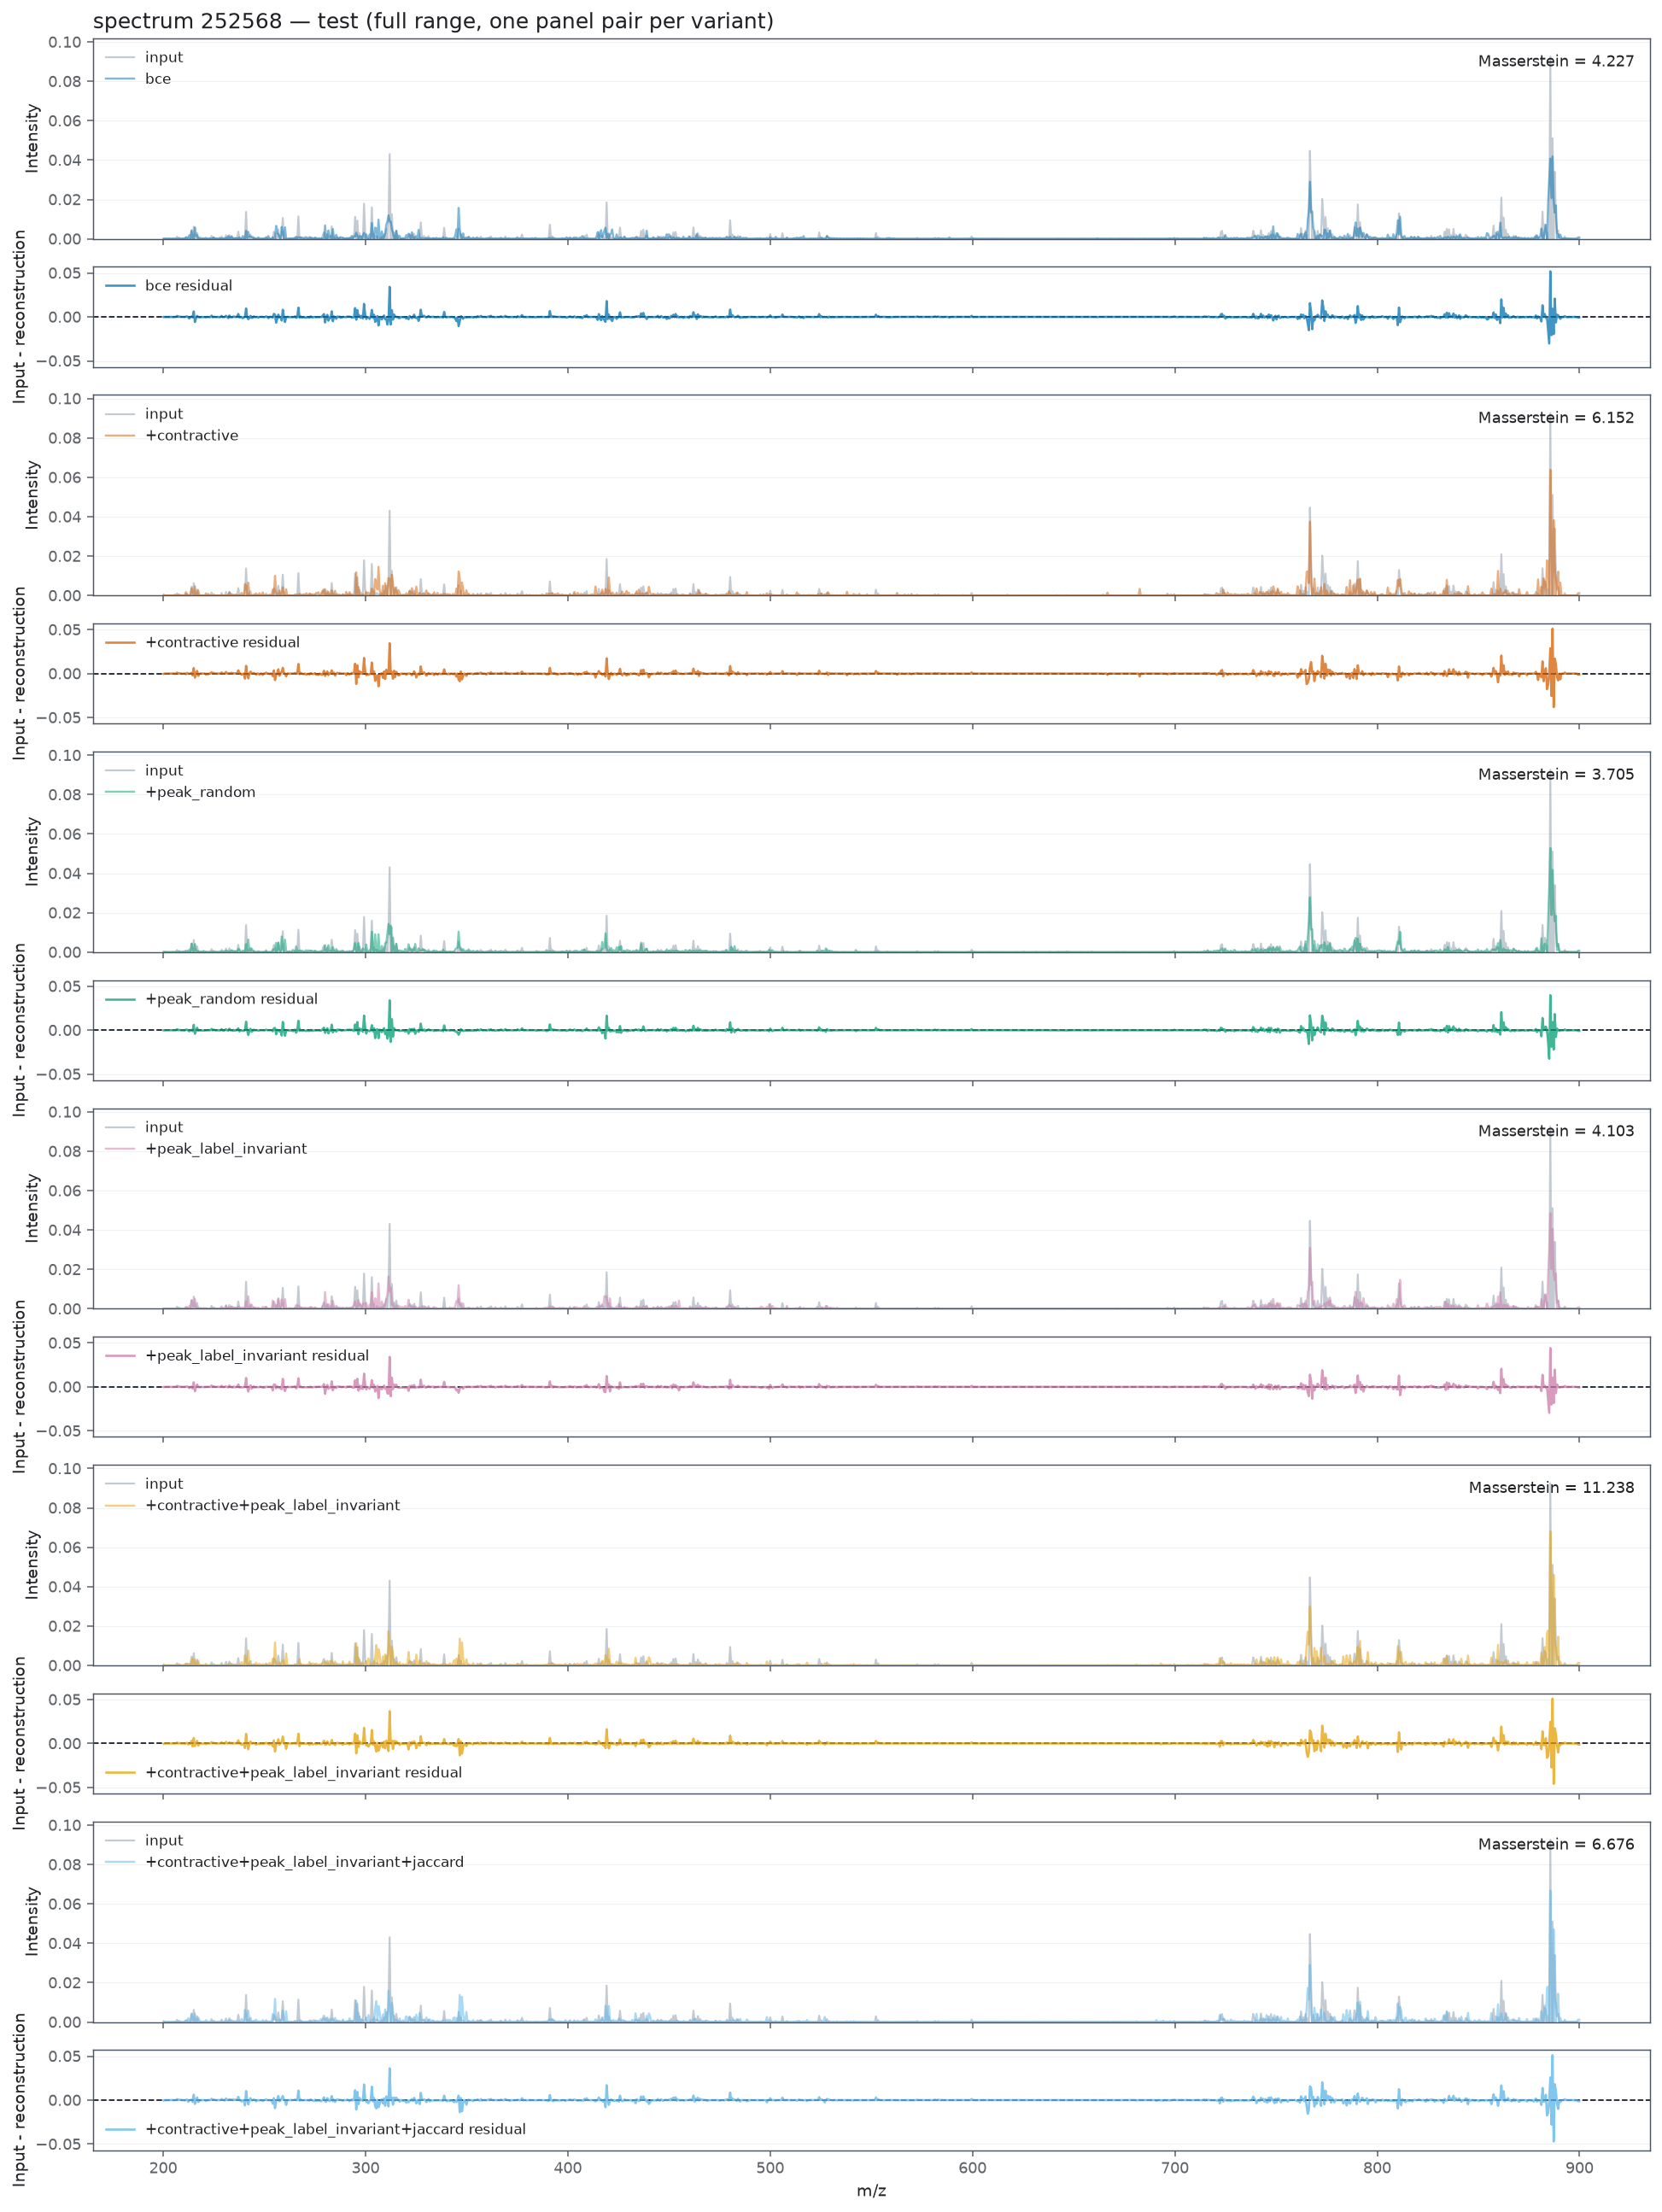

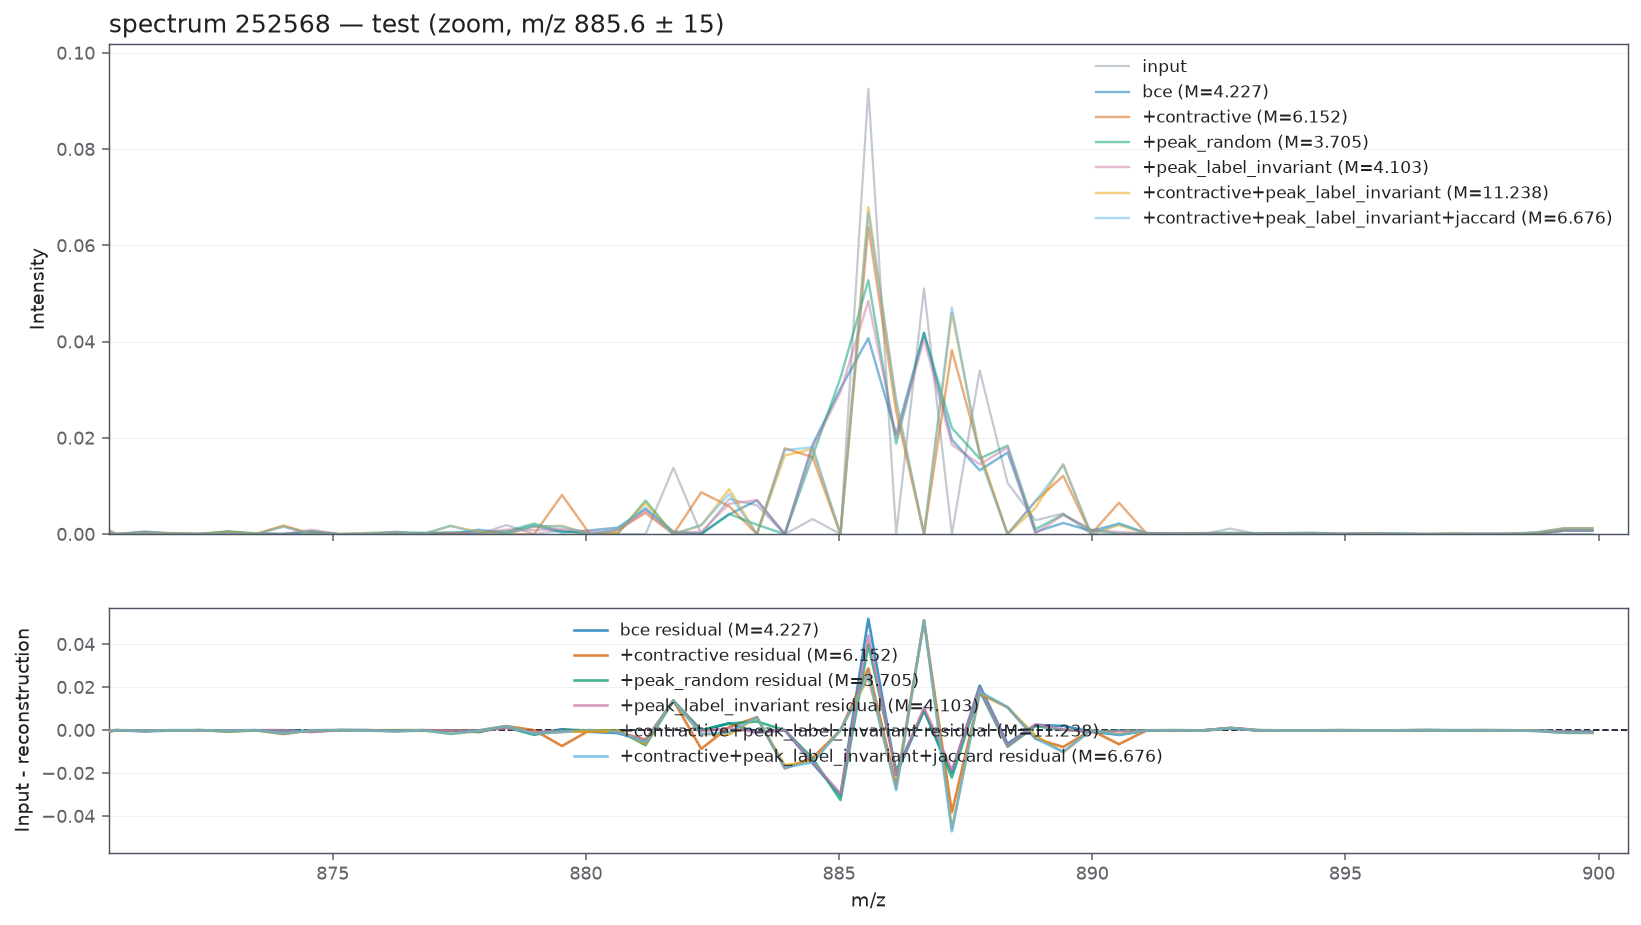

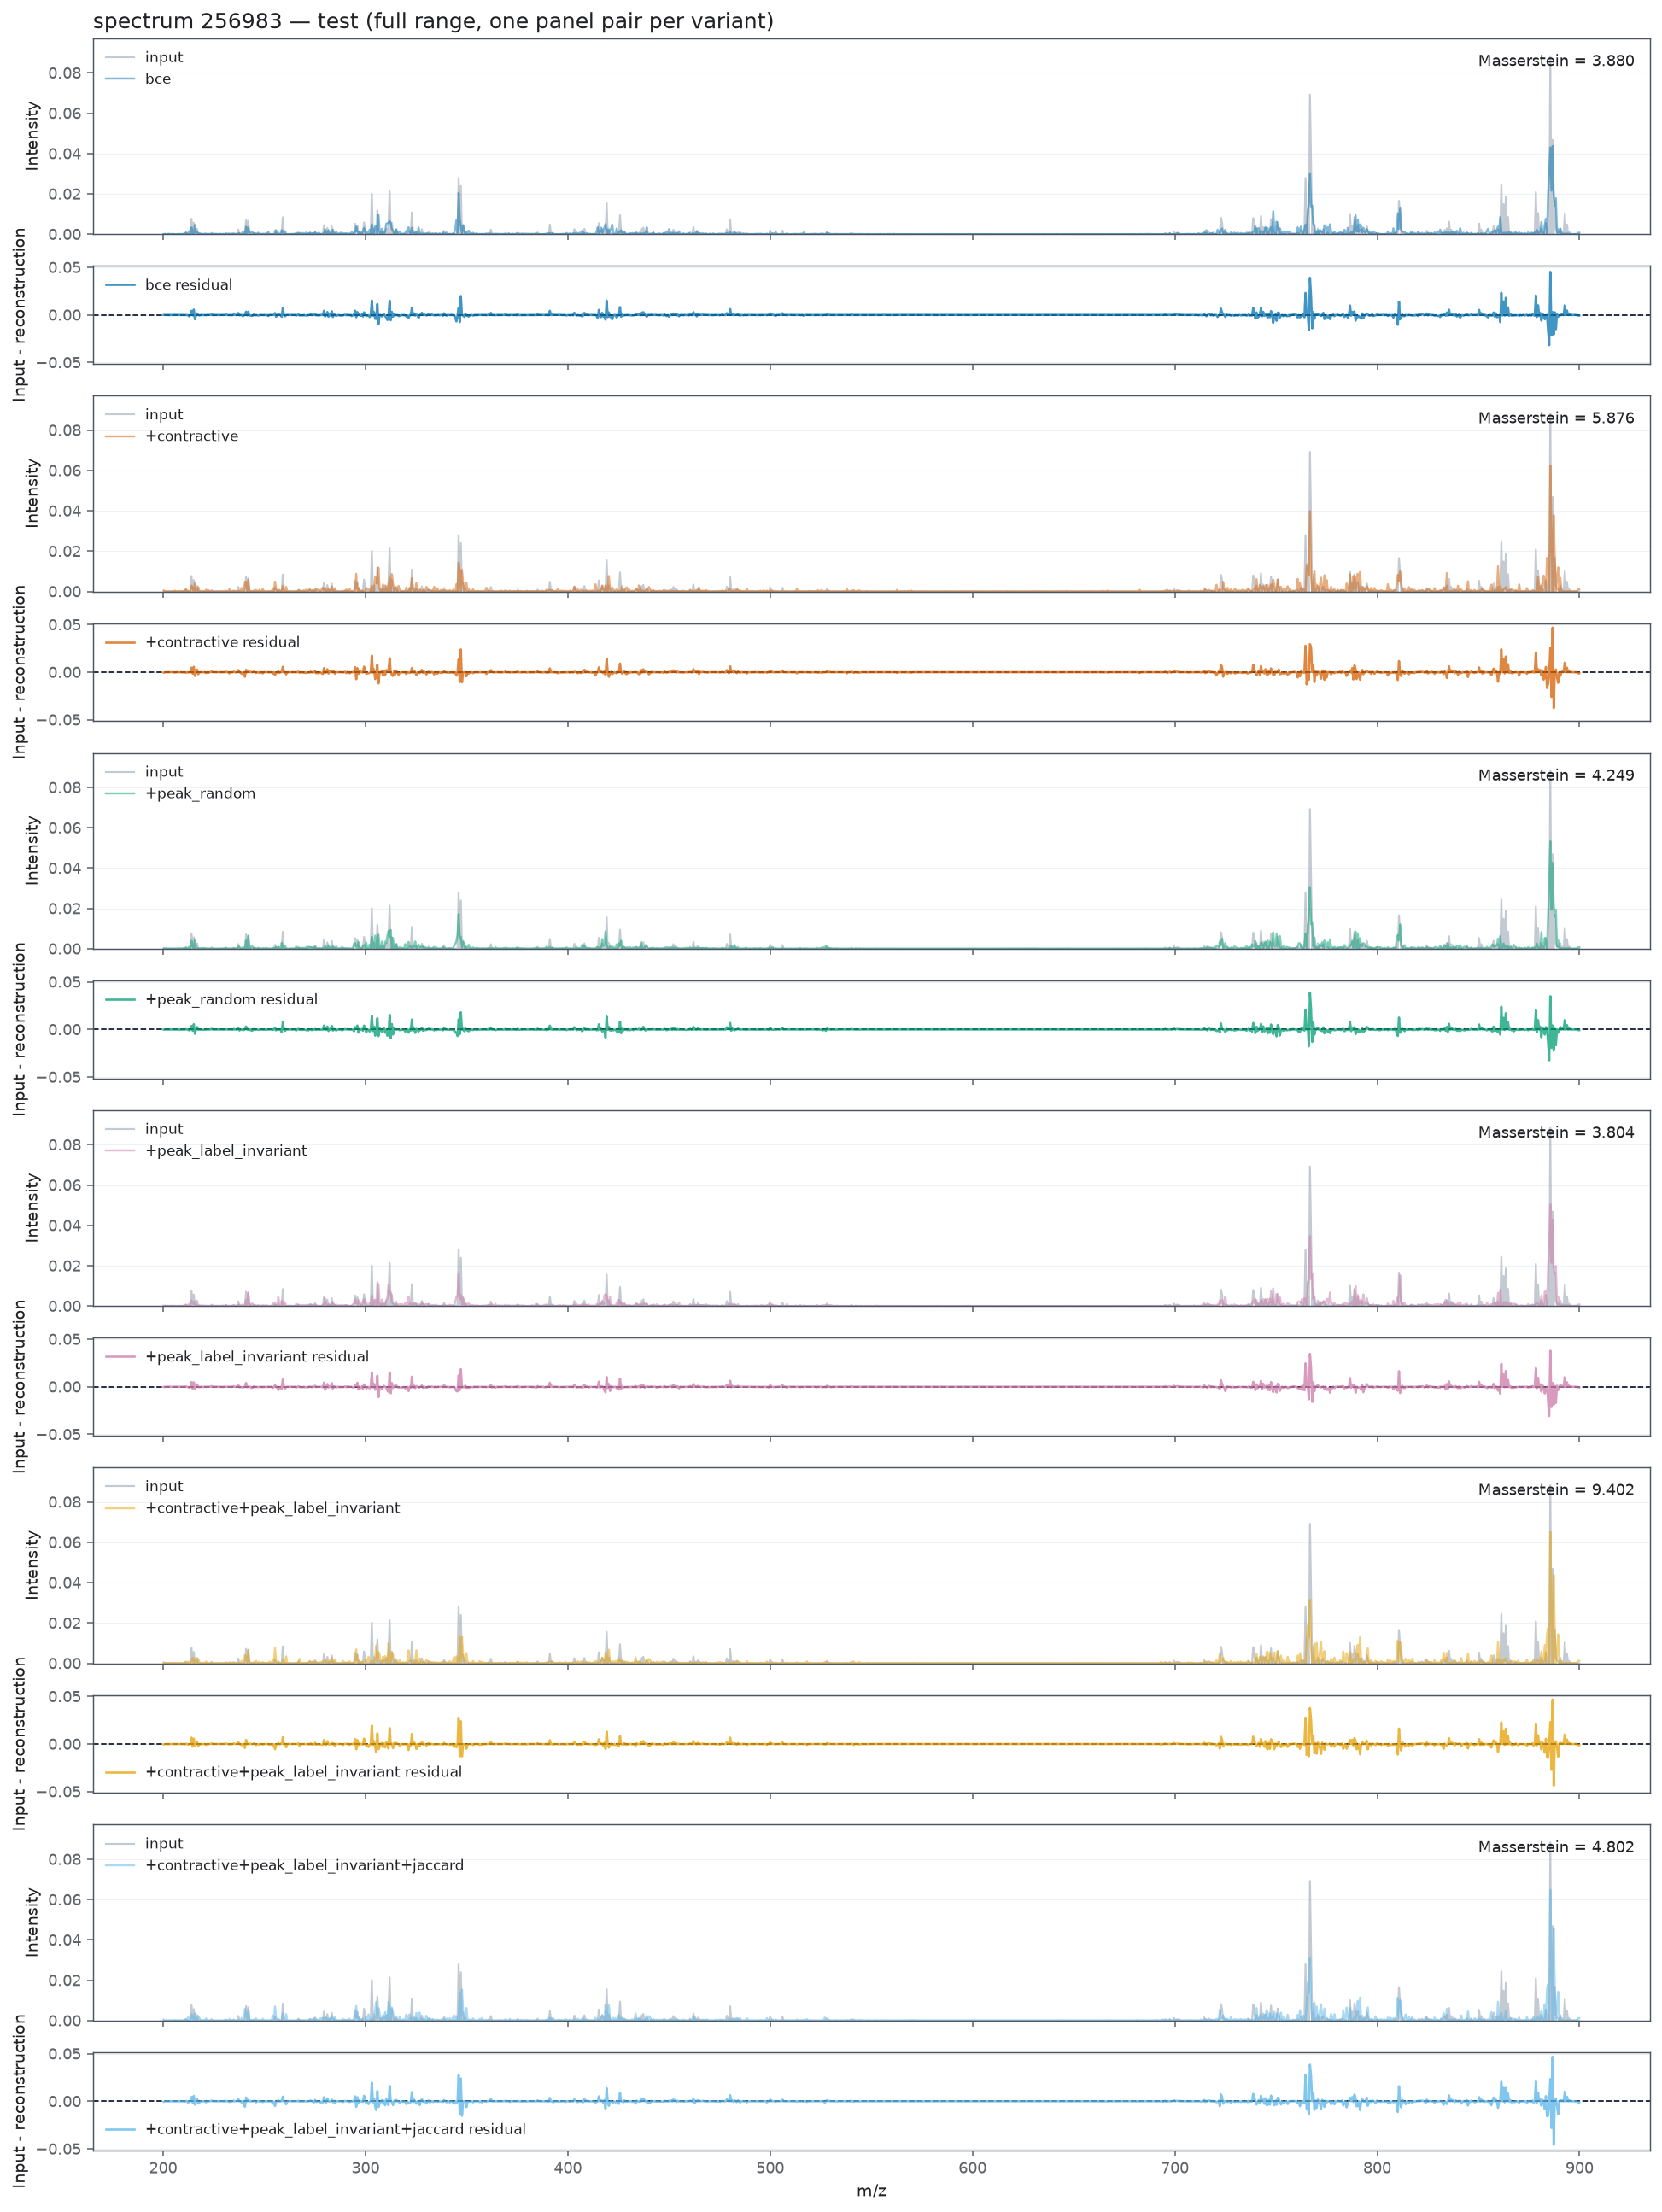

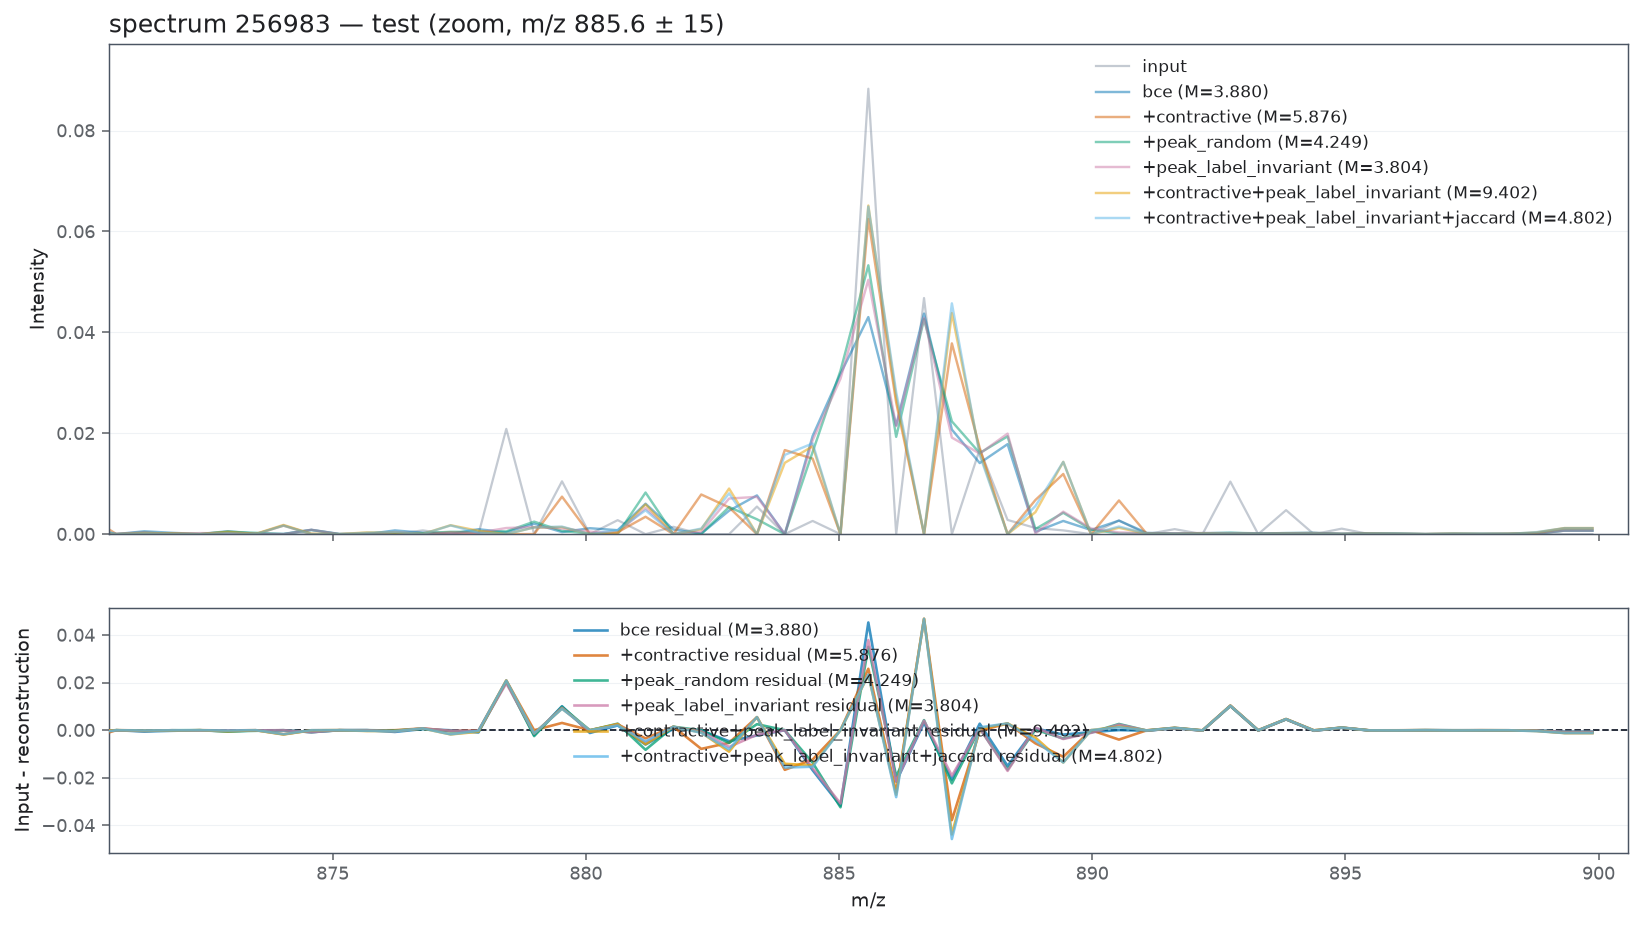

In [11]:
for spectrum_id in example_ids_by_split["test"]:
    plot_pixel(int(spectrum_id), "test")


## Notes for the next pass

**Headline: `+peak_label_invariant` alone is the best-performing single
reconstruction model in the family — adding `+contractive` on top of it
measurably *hurts* (a null-surviving degradation), and `+negw_multilabel_jaccard`
on top of that changes nothing further.** This overturns the working hypothesis
that `grid_0004` (`+contractive+peak_label_invariant`) would be the best model.

### Result (all 5 repetitions, validation Masserstein at best checkpoint)

| objective | mean | std | vs. predecessor | signal/null |
|---|---|---|---|---|
| `bce` | 35.14 | 7.56 | — | — |
| `+contractive` | 29.02 | 1.99 | vs. `bce`: 6.12 | 0.69 (no) |
| `+peak_random` | 23.87 | 3.76 | vs. `bce`: 11.27 | **1.26 (yes)** |
| `+peak_label_invariant` | **21.38** | 4.53 | vs. `bce`: 13.76 | **1.54 (yes)** |
| `+contractive+peak_label_invariant` (`grid_0004`) | 27.54 | 1.16 | vs. `+peak_label_invariant`: 6.16 (**worse**) | **1.12 (yes)** |
| `+contractive+peak_label_invariant+jaccard` (`grid_0005`) | 27.82 | 2.22 | vs. `grid_0004`: 0.28 | 0.11 (no) |

- **`+peak_label_invariant` (`grid_0003`) is the best reconstruction result in the
  whole family** — lowest mean (21.38), and the effect vs. `bce` survives the null
  check most comfortably of the single-term additions (ratio 1.54).
- **Adding `+contractive` on top of it (`grid_0003` → `grid_0004`) is a real,
  null-surviving *regression***: mean Masserstein rises from 21.38 to 27.54 (+6.16,
  signal/null 1.12 — clears the null, unlike `bce` vs. `+contractive` alone, which
  did not). This is the first place in the whole campaign where `+contractive`
  produces a *statistically distinguishable, negative* downstream effect, rather
  than "no detectable effect" (`part_5` original 4-objective pass, `part_6`). It
  lines up with `part_4`/`part_7`'s finding that `+contractive` is the only term
  whose latent-geometry change survives the null check (collapse,
  `cloud_asymmetry` 0.96) — here is a concrete downstream cost attributable to it.
- **`grid_0004` vs. `bce` itself does *not* survive the null** (7.60 diff, ratio
  0.85) — so `+contractive` pulls `+peak_label_invariant`'s clear win back down to
  "statistically indistinguishable from plain `bce`," even though the point
  estimate (27.54) still looks numerically better than `bce`'s mean (35.14). Read
  this as: combining the two terms does not clearly beat `bce`, whereas
  `+peak_label_invariant` alone clearly does.
- **`+negw_multilabel_jaccard` (`grid_0004` → `grid_0005`) changes nothing
  detectable** — 0.28 difference against a 2.63 null, ratio 0.11, the lowest of
  any comparison in this notebook. No evidence the Jaccard negative-weighting
  affects reconstruction quality in either direction, which is expected on priors
  (it only reweights the InfoNCE contrastive term's negatives, and does not touch
  the reconstruction loss directly).
- **The seed-tightening pattern continues and sharpens**: `grid_0004`'s own
  seed-to-seed null (mean 1.41, std 0.88) is *tighter* than plain `+contractive`'s
  (mean 2.32) — combining `+contractive` with `+peak_label_invariant` doesn't just
  keep the low-variance property, it strengthens it. `grid_0005`'s null widens
  again slightly (mean 2.63) but stays far below `bce`/`+peak_random`/
  `+peak_label_invariant`'s own nulls (4.46-8.93).

**Provisional balanced_bce-family conclusion for reconstruction**: if
reconstruction quality were the only criterion, `grid_0003`
(`+peak_label_invariant` alone, no `+contractive`) is the best model in this
family — not `grid_0004` or `grid_0005`. `part_6` (prediction) is the matching
test for the classification head; a full balanced_bce-family verdict needs both
read together before picking a single "best" model.
